# Task 4: Customer Segmentation


## Phần 1: Xây dựng customer-level master dataset


Mục tiêu của phần này là chuyển dữ liệu từ **customer–month** sang **1 dòng cho mỗi customer** trước khi thực hiện feature selection và phân cụm.

Nguyên tắc:
- Chưa loại biến chỉ vì tương quan cao hoặc chưa phù hợp với một thuật toán phân cụm cụ thể.
- Giữ thông tin về **mức độ điển hình**, **mức biến động**, **trạng thái gần nhất** và **xu hướng theo thời gian** khi chúng có ý nghĩa.
- Các thống kê tạo ra ở bước này thuộc **customer master table**; một số cột có thể dư thừa và sẽ được chọn lọc ở bước feature selection sau đó.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
)

FILE_PATH = "../data/consumer_financial_health_engagement_2025.csv"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
FINAL_K = 4


In [ ]:
df = pd.read_csv(
    "../data/consumer_financial_health_engagement_2025.csv"
)

df_copy = df.copy()

df["analysis_month"] = pd.to_datetime(
    df["analysis_month"]
)

df = df.sort_values(
    ["consumer_id", "analysis_month"]
).reset_index(drop=True)

df.head(3).T

,0,1,2
consumer_id,KH00100010,KH00100010,KH00100010
analysis_month,2025-01-01 00:00:00,2025-02-01 00:00:00,2025-03-01 00:00:00
age,27,27,27
gender,Nam,Nam,Nam
occupation,Kỹ sư sản xuất,Kỹ sư sản xuất,Kỹ sư sản xuất
province_city,Đồng Nai,Đồng Nai,Đồng Nai
monthly_income_vnd,1003930000,961510000,916740000
credit_limit_vnd,3780600000,3780600000,3780600000
opening_balance_vnd,501965000,1065133000,1627173000
ending_balance_vnd,1065133000,1627173000,2029964000


In [ ]:
# Kiểm tra các điều kiện tối thiểu trước khi tổng hợp theo customer
n_duplicate_customer_month = df.duplicated(["consumer_id", "analysis_month"]).sum()
month_coverage = (
    df.groupby("consumer_id")["analysis_month"]
      .nunique()
      .value_counts()
      .sort_index()
)

print("Số cặp consumer_id-analysis_month bị trùng:", n_duplicate_customer_month)
print("Số tháng quan sát trên mỗi customer:")
display(month_coverage.rename("n_customers").to_frame())

assert n_duplicate_customer_month == 0, (
    "Có customer-month bị trùng; cần xử lý trước khi aggregate."
)


Số cặp consumer_id-analysis_month bị trùng: 0
Số tháng quan sát trên mỗi customer:


,n_customers
analysis_month,
1,86
2,5
12,908


EDA ở Task 1 đã kiểm tra chất lượng dữ liệu tổng quát. Ở Task 4 chỉ kiểm tra lại các điều kiện trực tiếp ảnh hưởng đến phép tổng hợp:

- Mỗi cặp `consumer_id–analysis_month` phải là duy nhất.
- Bộ dữ liệu có **999 customer** nhưng độ dài quan sát không giống nhau: 908 customer có 12 tháng, 5 customer có 2 tháng và 86 customer có 1 tháng.
- Vì vậy `sum` cần được diễn giải cùng với `n_months_observed`; không nên so sánh trực tiếp tổng của các customer có độ dài cửa sổ quan sát khác nhau nếu chưa kiểm soát yếu tố này.
- Để customer master table **không chứa NaN/NULL**, các thống kê không thể ước lượng từ một thời điểm duy nhất được xử lý bằng quy ước rõ ràng: `std = 0` (độ lệch chuẩn quần thể của một giá trị) và `trend = 0` khi chỉ có một thời điểm. Cột `has_longitudinal_history` cho biết customer có đủ ít nhất 2 thời điểm để trend thực sự được ước lượng hay không.
- `next_month_low_health_flag` thiếu ở quan sát cuối của mỗi customer là hợp lý vì không còn tháng kế tiếp. Khi customer không có outcome tháng kế tiếp nào quan sát được, `count = 0`, `rate = 0` chỉ là **giá trị quy ước để tránh NaN**; phải đọc cùng `next_month_low_health_observed_count` và `next_month_low_health_available`.


### Thông tin cơ bản của customer

Các biến `age`, `gender`, `occupation`, `province_city` không thay đổi theo tháng trong cùng một customer nên lấy một giá trị đại diện bằng `first`.

Bổ sung:
- `age_group` và `occupation_group` để phục vụ profiling/diễn giải sau này.
- `n_months_observed`, `first_observed_month`, `last_observed_month` để mô tả độ phủ thời gian của từng customer.
- `has_longitudinal_history = 1` nếu customer có ít nhất 2 tháng quan sát, ngược lại bằng `0`. Cột này giúp phân biệt `trend = 0` do chuỗi thực sự phẳng với `trend = 0` được quy ước vì chỉ có một thời điểm.

`occupation_group` sử dụng cùng quy tắc phân nhóm nghề ở Task 2.


In [ ]:
OCC_RULES = [
 ('Nông nghiệp và môi trường', ['vật nuôi','chăn nuôi','Chuyên viên làm vườn','tư vấn làm vườn','cây','nông','Nông','lâm nghiệp','Kiểm lâm','thủy sản','môi trường','Môi trường','thổ nhưỡng','chọn giống','sinh thái','bảo tồn thiên nhiên','chất thải','nông trại']),
 ('Công nghệ thông tin', ['Lập trình','phần mềm','công nghệ thông tin','cơ sở dữ liệu','Kỹ sư mạng','phân tích hệ thống','hệ thống thông tin','khoa học dữ liệu','thiết kế web','Giám đốc công nghệ']),
 ('Y tế và chăm sóc sức khỏe', ['Bác sĩ','Dược','Trình dược','Điều dưỡng','trị liệu','Trị liệu','tâm lý','y tế','Y tế','y khoa','lâm sàng','cấp cứu','cứu thương','kính thuốc','đo mắt','chỉnh thị','châm cứu','bàn chân','nắn chỉnh','đông y','vi lượng','thính học','xạ trị','chẩn đoán hình ảnh','sinh lý vận động','dinh dưỡng','truyền thông sức khỏe','Thư ký y khoa','vệ sinh lao động','an toàn lao động']),
 ('Tài chính và pháp lý', ['Kế toán','kế toán','tài chính','Tài chính','ngân hàng','thuế','Thuế','bảo hiểm','bồi thường','giao dịch','Luật sư','pháp chế','pháp lý','Thư ký luật','phân tích rủi ro','phân tích đầu tư','hưu trí','công chứng']),
 ('Giáo dục', ['Giáo viên','Giảng viên','Giáo sư','giáo sư','Thủ thư','hướng nghiệp','giáo dục','Người hướng dẫn học tập','Nhà biên soạn từ điển']),
 ('Khoa học và nghiên cứu', ['Nhà khoa học','khoa học','Nhà địa','địa chất','địa chấn','địa vật lý','địa hóa','Nhà hóa','hóa sinh','di truyền','Nhà hải dương','Nhà vật lý','thủy văn','Nhà khảo cổ','Nhà kinh tế','Nhà luyện kim','Nhà miễn dịch','Nhà dược lý','Nhà độc chất','Nhà nghiên cứu','nghiên cứu','Nhà thống kê','phòng thí nghiệm','phân tích mẫu','Nhà văn khoa học','Nghiên cứu viên']),
 ('Kỹ thuật và xây dựng', ['Kỹ sư','Kiến trúc sư','kiến trúc','xây dựng','công trình','trắc địa','khảo sát','vẽ bản đồ','quy hoạch','Nhà thầu','Kỹ thuật viên','công nghệ dệt may','màu sắc','bảo trì','mỏ đá']),
 ('Truyền thông, nghệ thuật và thiết kế', ['Biên tập','biên tập','Nhà báo','Phóng viên','thiết kế','Họa sĩ','Nghệ sĩ','nghệ thuật','Nhạc sĩ','Vũ công','Đạo diễn','phim','hoạt hình','kỹ xảo','phát thanh','truyền hình','phát sóng','quảng cáo','truyền thông','quan hệ công chúng','trang điểm','Nhà văn','Nghệ nhân','trường quay','bối cảnh','sân khấu','nhà hát','phòng tranh','bảo tàng','phục chế','di sản','di tích','nội dung','Người quay phim','Thông dịch','Người dẫn chương trình','ánh sáng']),
 ('Khu vực công và cộng đồng', ['Cán bộ','Công chức','Cảnh sát','Sĩ quan','Lính cứu hỏa','trại giam','Thanh tra','cộng đồng','cứu trợ','từ thiện','tình nguyện','gây quỹ','chính trị','Chánh văn phòng','công đoàn','xuất nhập cảnh','tình báo','hỗ trợ','quản chế','đất đai']),
 ('Kinh doanh và dịch vụ', ['Giám đốc','giám đốc','Quản lý','Quản trị viên','kinh doanh','Chuyên viên nhân sự','thu mua','bán lẻ','trưng bày','tiếp thị','xúc tiến','Thư ký','thị trường','sự kiện','Người bán sách','du lịch','khách sạn','Phi công','Tiếp viên','Kiểm soát viên không lưu','giao nhận','môi giới','pha chế','Chuyên viên lưu trữ','bất động sản','sản phẩm','vận hành','tư vấn quản lý']),
]
# Những nghề mà từ khóa xếp chưa đúng, sửa tay
OCC_OVERRIDE = {
    'Nhà khoa học lâm sàng miễn dịch di truyền': 'Khoa học và nghiên cứu',
    'Nhà hóa sinh lâm sàng': 'Khoa học và nghiên cứu',
    'Chuyên viên nghiên cứu thị trường': 'Kinh doanh và dịch vụ',
    'Nhà thiết kế dệt may': 'Truyền thông, nghệ thuật và thiết kế',
    'Kỹ sư y sinh': 'Kỹ thuật và xây dựng',
    'Kỹ thuật viên phòng thí nghiệm giảng dạy': 'Giáo dục',
    'Giảng viên công nghệ thông tin': 'Công nghệ thông tin',
}

def occ_group(o):
    if o in OCC_OVERRIDE:
        return OCC_OVERRIDE[o]
    for g, kws in OCC_RULES:
        if any(k in o for k in kws):
            return g
    return 'Unmapped'

In [ ]:
customer_base = (
    df.groupby("consumer_id")
      .agg(
          age=("age", "first"),
          gender=("gender", "first"),
          occupation=("occupation", "first"),
          province_city=("province_city", "first"),

          n_months_observed=("analysis_month", "nunique"),
          first_observed_month=("analysis_month", "min"),
          last_observed_month=("analysis_month", "max"),
      )
)

customer_base['has_longitudinal_history'] = (
    customer_base['n_months_observed'] >= 2
).astype(int)

customer_base['occupation_group'] = customer_base['occupation'].map(occ_group)

# Định nghĩa các mốc và nhãn cho nhóm tuổi
age_bins = [0, 24, 34, 44, 54, 64, np.inf]
age_labels = ['<25', '25–34', '35–44', '45–54', '55–64', '65+']
customer_base['age_group'] = pd.cut(customer_base['age'], bins=age_bins, labels=age_labels, right=True)

# Reorder columns to place 'age_group' after 'age' and 'occupation_group' after 'occupation'
columns = customer_base.columns.tolist()
if 'age' in columns and 'age_group' in columns:
    columns.remove('age_group')
    age_index = columns.index('age')
    columns.insert(age_index + 1, 'age_group')

if 'occupation' in columns and 'occupation_group' in columns:
    columns.remove('occupation_group')
    occupation_index = columns.index('occupation')
    columns.insert(occupation_index + 1, 'occupation_group')

customer_base = customer_base[columns]

print('Số dòng chưa xếp được:', (customer_base['occupation_group'] == 'Unmapped').sum())   # phải bằng 0
display(customer_base.head())
customer_base.info()


Số dòng chưa xếp được: 0


,age,age_group,gender,occupation,occupation_group,province_city,n_months_observed,first_observed_month,last_observed_month,has_longitudinal_history
consumer_id,,,,,,,,,,
KH00100010,27,25–34,Nam,Kỹ sư sản xuất,Kỹ thuật và xây dựng,Đồng Nai,12,2025-01-01,2025-12-01,1
KH00100045,62,55–64,Nữ,Chuyên viên sinh lý vận động,Y tế và chăm sóc sức khỏe,Nghệ An,12,2025-01-01,2025-12-01,1
KH00100050,81,65+,Nữ,Nhà thiết kế dệt may,"Truyền thông, nghệ thuật và thiết kế",Cần Thơ,12,2025-01-01,2025-12-01,1
KH00100085,32,25–34,Nữ,Nhà địa vật lý,Khoa học và nghiên cứu,Thành phố Hồ Chí Minh,12,2025-01-01,2025-12-01,1
KH00100090,18,<25,Nam,Kỹ sư hóa học,Kỹ thuật và xây dựng,Tuyên Quang,2,2025-09-01,2025-10-01,1


<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, KH00100010 to KH00119970
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   age                       999 non-null    int64         
 1   age_group                 999 non-null    category      
 2   gender                    999 non-null    object        
 3   occupation                999 non-null    object        
 4   occupation_group          999 non-null    object        
 5   province_city             999 non-null    object        
 6   n_months_observed         999 non-null    int64         
 7   first_observed_month      999 non-null    datetime64[ns]
 8   last_observed_month       999 non-null    datetime64[ns]
 9   has_longitudinal_history  999 non-null    int64         
dtypes: category(1), datetime64[ns](2), int64(3), object(4)
memory usage: 79.2+ KB


### Hàm tính trend

`trend` được xấp xỉ bằng hệ số góc của hồi quy tuyến tính đơn:

\[
x_t = \beta_0 + \beta_1 t + \varepsilon_t
\]

Trong đó `t` là **số tháng thực tế** tính từ tháng quan sát đầu tiên của customer. Giá trị `trend = β₁` có đơn vị là mức thay đổi của biến trong một tháng:
- `trend > 0`: có xu hướng tăng;
- `trend < 0`: có xu hướng giảm;
- `trend ≈ 0`: tương đối ổn định.

Để bảng customer-level không chứa `NaN`, customer có ít hơn 2 thời điểm hợp lệ được quy ước `trend = 0`. Quy ước này **không khẳng định customer thực sự không có xu hướng**; cần đọc cùng `has_longitudinal_history`. Nếu `has_longitudinal_history = 0`, trend chỉ là giá trị thay thế kỹ thuật.


In [ ]:
def calc_trend(x, dates):
    """Ước lượng độ dốc theo số tháng thực tế giữa các quan sát.

    Quy ước trend = 0 khi có dưới 2 thời điểm hợp lệ để customer-level
    master table không phát sinh NaN. Dùng has_longitudinal_history để
    phân biệt trường hợp này với một chuỗi thực sự có độ dốc gần 0.
    """
    mask = x.notna() & dates.notna()
    x_valid = x.loc[mask]
    dates_valid = dates.loc[mask]

    if len(x_valid) < 2:
        return 0.0

    month_index = (
        dates_valid.dt.year * 12
        + dates_valid.dt.month
    ).astype(float)
    month_index = month_index - month_index.iloc[0]

    if month_index.nunique() < 2:
        return 0.0

    return float(
        np.polyfit(
            month_index.values,
            x_valid.astype(float).values,
            1,
        )[0]
    )


### Hàm hỗ trợ tổng hợp theo customer

Hàm `aggregate()` hỗ trợ các thống kê `sum`, `mean`, `median`, `std`, `min`, `max`, `first`, `last`, `change`, `trend`, `count`, `nunique`, `mode`.

Không phải nhóm biến nào cũng sử dụng tất cả các thống kê. Việc chọn thống kê ở từng nhóm dựa trên ý nghĩa của biến:
- `sum`: chỉ dùng khi tổng qua các tháng có ý nghĩa.
- `std`: dùng **độ lệch chuẩn quần thể (`ddof=0`)** vì các tháng quan sát được của customer chính là cửa sổ thời gian cần mô tả; với một quan sát, `std = 0`, nhờ đó không phát sinh NaN.
- `last`: dùng khi trạng thái gần nhất có ý nghĩa.
- `change = last - first`: chỉ dùng khi chênh lệch hai đầu mút có diễn giải rõ; **không dùng cho nhóm flow** vì dễ bị chi phối bởi hai tháng đơn lẻ. Nếu chỉ có một giá trị hợp lệ thì quy ước `change = 0`.
- `trend`: dùng toàn bộ chuỗi theo thời gian; nếu chỉ có một thời điểm hợp lệ thì quy ước `trend = 0` và đọc cùng `has_longitudinal_history`.
- Nếu một biến numeric hoàn toàn thiếu trong một customer, hàm dùng `0`; nếu một biến categorical hoàn toàn thiếu, dùng nhãn `"Unknown"`. Dataset gốc hiện tại không có trường hợp này ngoài outcome tháng kế tiếp được xử lý riêng, nhưng quy tắc giúp hàm không tạo NaN ngoài ý muốn.


In [ ]:
def aggregate(data, variables, stats=None):
    if stats is None:
        stats = []

    rows = []

    for customer_id, group in data.groupby("consumer_id"):
        group = group.sort_values("analysis_month")
        row = {"consumer_id": customer_id}

        for col in variables:
            x = group[col]
            x_nonmissing = x.dropna()
            is_numeric = pd.api.types.is_numeric_dtype(x)
            empty_default = 0.0 if is_numeric else "Unknown"

            if "sum" in stats:
                row[f"{col}_sum"] = (
                    x_nonmissing.sum() if len(x_nonmissing) else 0.0
                )

            if "mean" in stats:
                row[f"{col}_mean"] = (
                    x_nonmissing.mean() if len(x_nonmissing) else 0.0
                )

            if "median" in stats:
                row[f"{col}_median"] = (
                    x_nonmissing.median() if len(x_nonmissing) else 0.0
                )

            if "std" in stats:
                # Population SD: one valid observation -> 0, not NaN.
                row[f"{col}_std"] = (
                    x_nonmissing.std(ddof=0) if len(x_nonmissing) else 0.0
                )

            if "min" in stats:
                row[f"{col}_min"] = (
                    x_nonmissing.min() if len(x_nonmissing) else empty_default
                )

            if "max" in stats:
                row[f"{col}_max"] = (
                    x_nonmissing.max() if len(x_nonmissing) else empty_default
                )

            if "first" in stats:
                row[f"{col}_first"] = (
                    x_nonmissing.iloc[0] if len(x_nonmissing) else empty_default
                )

            if "last" in stats:
                row[f"{col}_last"] = (
                    x_nonmissing.iloc[-1] if len(x_nonmissing) else empty_default
                )

            if "change" in stats:
                row[f"{col}_change"] = (
                    x_nonmissing.iloc[-1] - x_nonmissing.iloc[0]
                    if len(x_nonmissing) >= 2
                    else 0.0
                )

            if "trend" in stats:
                row[f"{col}_trend"] = calc_trend(
                    x,
                    group["analysis_month"],
                )

            if "count" in stats:
                row[f"{col}_count"] = int(x.count())

            if "nunique" in stats:
                row[f"{col}_nunique"] = int(x.nunique(dropna=True))

            if "mode" in stats:
                mode = x.mode(dropna=True)
                row[f"{col}_mode"] = (
                    mode.iloc[0] if len(mode) else empty_default
                )

        rows.append(row)

    return pd.DataFrame(rows).set_index("consumer_id")


### Chiến lược tổng hợp theo nhóm biến

| Nhóm | Bản chất | Thống kê chính | Ghi chú |
|---|---|---|---|
| Flow / activity | Lượng hoạt động phát sinh trong tháng | `sum`, `mean`, `std`, `min`, `max`, `trend` | Không dùng `change = last-first`; `sum` phụ thuộc số tháng quan sát |
| State / behavior | Mức trạng thái tại từng tháng | `mean`, `std`, `min`, `max`, `last`, `trend` | `last` giữ trạng thái gần nhất; không cộng dồn |
| Ratio | Tỷ lệ tại từng tháng | `mean`, `std`, `min`, `max`, `last`, `trend` | Không dùng `sum`; `max` hữu ích cho các tỷ lệ rủi ro |
| Score | Điểm engagement/financial health | `mean`, `std`, `min`, `max`, `last`, `trend` | Giữ cả mức điển hình, cực trị, hiện tại và xu hướng |
| Segment | Nhãn phân loại theo tháng | `first`, `last`, `mode`, `nunique`, `transitions` | Mô tả trạng thái đầu/cuối, trạng thái điển hình và độ ổn định |
| Credit/balance | Biến stock | xử lý riêng | Credit limit bất biến; balance dùng mức đầu, mức cuối, mức điển hình và net change |


### Nhóm 1 — Flow / activity

Các biến:
`total_spend_vnd`, `essential_spend_vnd`, `discretionary_spend_vnd`, `online_spend_vnd`, `transaction_count`, `active_transaction_days`.

Đây là các biến biểu diễn **lượng hoạt động phát sinh trong tháng**. Tổng qua các tháng có ý nghĩa mô tả tổng mức hoạt động trong cửa sổ quan sát, vì vậy giữ `sum`. Đồng thời giữ `mean`, `std`, `min`, `max` để mô tả mức điển hình và độ phân tán, cùng `trend` để mô tả xu hướng.

Không dùng `first`, `last` hay `change = last-first` cho nhóm này vì hai tháng đầu/cuối đơn lẻ không đại diện tốt cho hướng thay đổi. Lưu ý `sum` chỉ so sánh công bằng khi độ dài quan sát tương đương hoặc đã được kiểm soát bằng `n_months_observed`.


In [ ]:
flow_activity_vars = [
    "total_spend_vnd",
    "essential_spend_vnd",
    "discretionary_spend_vnd",
    "online_spend_vnd",
    "transaction_count",
    "active_transaction_days",
]


In [ ]:
customer_flow_activity = aggregate(
    df,
    flow_activity_vars,
    stats=["sum", "mean", "std", "min", "max", "trend"]
)

display(customer_flow_activity.head().T)
customer_flow_activity.info()


consumer_id,KH00100010,KH00100045,KH00100050,KH00100085,KH00100090
total_spend_vnd_sum,7.036618e+09,2.539338e+09,2.390488e+09,4.693772e+09,1.998440e+08
total_spend_vnd_mean,5.863848e+08,2.116115e+08,1.992073e+08,3.911477e+08,9.992200e+07
total_spend_vnd_std,1.775024e+08,6.372299e+07,4.616514e+07,9.899155e+07,2.342100e+07
total_spend_vnd_min,3.994700e+08,1.281450e+08,1.407400e+08,2.284530e+08,7.650100e+07
total_spend_vnd_max,1.095423e+09,3.477330e+08,3.065450e+08,6.295580e+08,1.233430e+08
total_spend_vnd_trend,2.942343e+07,4.656308e+06,1.282077e+06,2.071736e+07,-4.684200e+07
essential_spend_vnd_sum,2.696137e+09,1.177912e+09,1.195537e+09,2.098500e+09,2.880000e+05
essential_spend_vnd_mean,2.246781e+08,9.815933e+07,9.962808e+07,1.748750e+08,1.440000e+05
essential_spend_vnd_std,7.445475e+07,3.444150e+07,3.126238e+07,4.511644e+07,1.440000e+05
essential_spend_vnd_min,1.383550e+08,6.595700e+07,6.980300e+07,9.301000e+07,0.000000e+00


<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, KH00100010 to KH00119970
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   total_spend_vnd_sum            999 non-null    int64  
 1   total_spend_vnd_mean           999 non-null    float64
 2   total_spend_vnd_std            999 non-null    float64
 3   total_spend_vnd_min            999 non-null    int64  
 4   total_spend_vnd_max            999 non-null    int64  
 5   total_spend_vnd_trend          999 non-null    float64
 6   essential_spend_vnd_sum        999 non-null    int64  
 7   essential_spend_vnd_mean       999 non-null    float64
 8   essential_spend_vnd_std        999 non-null    float64
 9   essential_spend_vnd_min        999 non-null    int64  
 10  essential_spend_vnd_max        999 non-null    int64  
 11  essential_spend_vnd_trend      999 non-null    float64
 12  discretionary_spend_vnd_sum    999 non-

### Nhóm 2 — State / behavioral variables

Các biến:
`monthly_income_vnd`, `average_transaction_value_vnd`, `category_diversity`, `transaction_recency_days`, `spending_volatility`.

Các biến này mô tả **mức trạng thái/hành vi tại từng tháng**, vì vậy `sum` không có diễn giải tự nhiên. Sử dụng:
- `mean`, `std`, `min`, `max`: mô tả mức điển hình và phạm vi biến động;
- `last`: giữ trạng thái gần nhất;
- `trend`: mô tả hướng thay đổi theo thời gian.

Không dùng `change = last-first` vì chỉ phụ thuộc hai đầu mút và dễ bị ảnh hưởng bởi tháng bất thường. Riêng `transaction_recency_days`, `last` đặc biệt hữu ích để mô tả mức độ gần đây của giao dịch ở thời điểm cuối quan sát.


In [ ]:
state_behavior_vars = [
    "monthly_income_vnd",
    "average_transaction_value_vnd",
    "category_diversity",
    "transaction_recency_days",
    "spending_volatility",
]


In [ ]:
customer_state_behavior = aggregate(
    df,
    state_behavior_vars,
    stats=["mean", "std", "min", "max", "last", "trend"]
)

display(customer_state_behavior.head().T)
customer_state_behavior.info()


consumer_id,KH00100010,KH00100045,KH00100050,KH00100085,KH00100090
monthly_income_vnd_mean,9.888958e+08,3.393067e+08,2.515875e+08,5.971050e+08,1.903800e+08
monthly_income_vnd_std,6.402402e+07,1.788969e+07,1.417646e+07,3.418219e+07,1.165000e+07
monthly_income_vnd_min,8.823300e+08,2.972400e+08,2.299600e+08,5.480200e+08,1.787300e+08
monthly_income_vnd_max,1.071580e+09,3.571600e+08,2.741400e+08,6.411500e+08,2.020300e+08
monthly_income_vnd_last,1.062000e+09,3.436000e+08,2.741400e+08,6.024700e+08,1.787300e+08
monthly_income_vnd_trend,4.776259e+06,-2.303636e+06,-5.040210e+05,-2.749161e+06,-2.330000e+07
average_transaction_value_vnd_mean,2.399369e+06,1.755498e+06,1.706454e+06,2.153896e+06,1.646031e+07
average_transaction_value_vnd_std,1.560187e+05,4.711767e+05,5.819655e+05,2.088344e+05,1.160114e+06
average_transaction_value_vnd_min,2.191627e+06,1.349118e+06,1.221180e+06,1.793456e+06,1.530020e+07
average_transaction_value_vnd_max,2.746371e+06,3.192980e+06,3.518520e+06,2.400160e+06,1.762043e+07


<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, KH00100010 to KH00119970
Data columns (total 30 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   monthly_income_vnd_mean              999 non-null    float64
 1   monthly_income_vnd_std               999 non-null    float64
 2   monthly_income_vnd_min               999 non-null    int64  
 3   monthly_income_vnd_max               999 non-null    int64  
 4   monthly_income_vnd_last              999 non-null    int64  
 5   monthly_income_vnd_trend             999 non-null    float64
 6   average_transaction_value_vnd_mean   999 non-null    float64
 7   average_transaction_value_vnd_std    999 non-null    float64
 8   average_transaction_value_vnd_min    999 non-null    int64  
 9   average_transaction_value_vnd_max    999 non-null    int64  
 10  average_transaction_value_vnd_last   999 non-null    int64  
 11  average_transaction_v

### Nhóm 3 — Ratio variables

Các biến:
`essential_spend_ratio`, `discretionary_spend_ratio`, `online_spend_ratio`, `spend_to_income_ratio`, `credit_utilization_ratio`.

Vì đây là các tỷ lệ nên **không cộng dồn bằng `sum`**. Sử dụng `mean`, `std`, `min`, `max`, `last`, `trend`:
- `mean` mô tả tỷ lệ điển hình;
- `std` mô tả độ ổn định;
- `min`/`max` mô tả phạm vi, trong đó `max` đặc biệt có ý nghĩa với `spend_to_income_ratio` và `credit_utilization_ratio`;
- `last` giữ trạng thái gần nhất;
- `trend` mô tả hướng thay đổi theo thời gian.


In [ ]:
ratio_vars = [
    "essential_spend_ratio",
    "discretionary_spend_ratio",
    "online_spend_ratio",
    "spend_to_income_ratio",
    "credit_utilization_ratio",
]


In [ ]:
customer_ratios = aggregate(
    df,
    ratio_vars,
    stats=["mean", "std", "min", "max", "last", "trend"]
)

display(customer_ratios.head().T)
customer_ratios.info()


consumer_id,KH00100010,KH00100045,KH00100050,KH00100085,KH00100090
essential_spend_ratio_mean,0.381114,0.476878,0.504853,0.450735,0.001167
essential_spend_ratio_std,0.026930,0.111401,0.104010,0.062068,0.001167
essential_spend_ratio_min,0.313900,0.226137,0.344065,0.379560,0.000000
essential_spend_ratio_max,0.416780,0.664400,0.690550,0.593138,0.002335
essential_spend_ratio_last,0.399288,0.575640,0.633656,0.456222,0.000000
essential_spend_ratio_trend,0.004368,0.006820,0.013201,0.004301,-0.002335
discretionary_spend_ratio_mean,0.618886,0.523122,0.495147,0.549265,0.998833
discretionary_spend_ratio_std,0.026930,0.111401,0.104010,0.062068,0.001167
discretionary_spend_ratio_min,0.583220,0.335600,0.309450,0.406862,0.997665
discretionary_spend_ratio_max,0.686100,0.773863,0.655935,0.620440,1.000000


<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, KH00100010 to KH00119970
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   essential_spend_ratio_mean       999 non-null    float64
 1   essential_spend_ratio_std        999 non-null    float64
 2   essential_spend_ratio_min        999 non-null    float64
 3   essential_spend_ratio_max        999 non-null    float64
 4   essential_spend_ratio_last       999 non-null    float64
 5   essential_spend_ratio_trend      999 non-null    float64
 6   discretionary_spend_ratio_mean   999 non-null    float64
 7   discretionary_spend_ratio_std    999 non-null    float64
 8   discretionary_spend_ratio_min    999 non-null    float64
 9   discretionary_spend_ratio_max    999 non-null    float64
 10  discretionary_spend_ratio_last   999 non-null    float64
 11  discretionary_spend_ratio_trend  999 non-null    float64
 12  online_spen

### Nhóm 4 — Engagement, financial health và outcome tháng kế tiếp

**Trạng thái sức khỏe tài chính hiện tại**
   - `n_months_low_health`: số tháng trong thời gian quan sát mà `financial_health_score < 40`.
   - `low_health_rate`: tỷ lệ số tháng có sức khỏe tài chính thấp trên tổng số tháng quan sát của customer.
   - Trong dữ liệu gốc, điều kiện `financial_health_score < 40` tương ứng với segment **"Có dấu hiệu căng thẳng tài chính"**.

Ngoài ra:
- `engagement_score` và `financial_health_score` dùng `mean`, `std`, `min`, `max`, `last`, `trend`.
- `engagement_segment` và `financial_health_segment` dùng `first`, `last`, `mode`, `nunique` và số lần chuyển trạng thái (`transitions`).
- Segment suy ra từ điểm trung bình được đặt tên `*_segment_from_mean_score` để phân biệt với segment quan sát theo từng tháng.


In [ ]:
score_vars = [
    "engagement_score",
    "financial_health_score",
]

segment_vars = [
    "engagement_segment",
    "financial_health_segment",
]


In [ ]:
customer_scores = aggregate(
    df,
    score_vars,
    stats=["mean", "std", "min", "max", "last", "trend"]
)

customer_segments = aggregate(
    df,
    segment_vars,
    stats=["first", "last", "mode", "nunique"]
)


def count_transitions(x):
    x = x.dropna().values
    if len(x) < 2:
        return 0
    return int(np.sum(x[1:] != x[:-1]))


customer_segment_transitions = (
    df.sort_values(["consumer_id", "analysis_month"])
      .groupby("consumer_id")
      .agg(
          engagement_segment_transitions=(
              "engagement_segment", count_transitions
          ),
          financial_health_segment_transitions=(
              "financial_health_segment", count_transitions
          ),
      )
)


# Ngưỡng được viết theo đúng quy ước segment trong dữ liệu gốc.
def classify_engagement_mean_score(score):
    if score >= 80:
        return "Tương tác rất cao"
    elif score >= 60:
        return "Tương tác cao"
    elif score >= 40:
        return "Tương tác trung bình"
    else:
        return "Tương tác thấp"


def classify_financial_health_mean_score(score):
    if score >= 80:
        return "Khỏe mạnh"
    elif score >= 60:
        return "Ổn định"
    elif score >= 40:
        return "Cần theo dõi"
    else:
        return "Có dấu hiệu căng thẳng tài chính"


customer_score_segments = pd.DataFrame(index=customer_scores.index)
customer_score_segments["engagement_segment_from_mean_score"] = (
    customer_scores["engagement_score_mean"]
    .apply(classify_engagement_mean_score)
)
customer_score_segments["financial_health_segment_from_mean_score"] = (
    customer_scores["financial_health_score_mean"]
    .apply(classify_financial_health_mean_score)
)


# ------------------------------------------------------
# A. Low health của THÁNG HIỆN TẠI
# ------------------------------------------------------
# Trong dữ liệu gốc: score < 40 <=> segment
# "Có dấu hiệu căng thẳng tài chính".
df["is_low_health"] = (
    df["financial_health_score"] < 40
).astype(int)

customer_current_health = (
    df.groupby("consumer_id")
      .agg(
          n_months_low_health=("is_low_health", "sum"),
          low_health_rate=("is_low_health", "mean"),
      )
)

customer_current_health["n_months_low_health"] = (
    customer_current_health["n_months_low_health"].astype(int)
)

customer_engagement_health = pd.concat(
    [
        customer_scores,
        customer_segments,
        customer_segment_transitions,
        customer_score_segments,
        customer_current_health,
    ],
    axis=1,
)

# Kiểm tra logic và missing.
assert customer_engagement_health.isna().sum().sum() == 0

display(customer_engagement_health.head().T)
customer_engagement_health.info()



consumer_id,KH00100010,KH00100045,KH00100050,KH00100085,KH00100090
engagement_score_mean,78.291667,77.425,78.7,80.441667,49.25
engagement_score_std,0.792105,4.699668,3.701576,3.663664,6.15
engagement_score_min,77.1,72.6,73.6,75.7,43.1
engagement_score_max,79.5,90.9,86.6,87.3,55.4
engagement_score_last,78.1,77.5,77.1,83.0,43.1
engagement_score_trend,0.106643,-0.133217,0.152448,0.001748,-12.3
financial_health_score_mean,70.616667,68.483333,60.958333,67.516667,67.85
financial_health_score_std,5.10177,7.490976,7.377721,5.801556,3.85
financial_health_score_min,57.0,53.8,45.2,55.8,64.0
financial_health_score_max,76.3,80.4,71.2,76.9,71.7


<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, KH00100010 to KH00119970
Data columns (total 26 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   engagement_score_mean                     999 non-null    float64
 1   engagement_score_std                      999 non-null    float64
 2   engagement_score_min                      999 non-null    float64
 3   engagement_score_max                      999 non-null    float64
 4   engagement_score_last                     999 non-null    float64
 5   engagement_score_trend                    999 non-null    float64
 6   financial_health_score_mean               999 non-null    float64
 7   financial_health_score_std                999 non-null    float64
 8   financial_health_score_min                999 non-null    float64
 9   financial_health_score_max                999 non-null    float64
 10  financial_health_score_last

### Nhóm 5 — Credit limit và balance

Ba biến `credit_limit_vnd`, `opening_balance_vnd`, `ending_balance_vnd` là **stock variables**, nên không nên cộng dồn qua các tháng.

Kiểm tra dữ liệu cho thấy:
- `credit_limit_vnd` không đổi trong cùng một customer → chỉ cần giữ một giá trị và đặt tên trực tiếp là `credit_limit_vnd` thay vì `credit_limit_vnd_first`.
- `opening_balance_vnd` của tháng sau bằng `ending_balance_vnd` của tháng trước → hai chuỗi balance mang thông tin liên tục, không cần aggregate cả hai theo cùng một cách.

Do đó giữ:
- `opening_balance_vnd_first`: số dư đầu kỳ đầu tiên;
- các thống kê `mean`, `std`, `min`, `max`, `last`, `trend` của `ending_balance_vnd` để mô tả đường đi của balance;
- `balance_net_change_vnd = ending_balance_vnd_last - opening_balance_vnd_first` để mô tả thay đổi ròng trong toàn bộ cửa sổ quan sát.


In [ ]:
# Kiểm tra credit limit có bất biến theo customer hay không
unique_credit_limits = (
    df.groupby("consumer_id")["credit_limit_vnd"]
      .nunique(dropna=False)
)

print(
    "Số customer có credit_limit thay đổi:",
    (unique_credit_limits > 1).sum()
)

# Kiểm tra tính liên tục của balance:
# opening_balance tháng hiện tại phải bằng ending_balance tháng trước.
df_balance_check = df.sort_values(["consumer_id", "analysis_month"]).copy()
df_balance_check["previous_ending_balance"] = (
    df_balance_check.groupby("consumer_id")["ending_balance_vnd"].shift(1)
)

balance_mismatch = (
    df_balance_check["previous_ending_balance"].notna()
    & (
        df_balance_check["opening_balance_vnd"]
        != df_balance_check["previous_ending_balance"]
    )
)

print("Số dòng balance không liên tục:", balance_mismatch.sum())


Số customer có credit_limit thay đổi: 0
Số dòng balance không liên tục: 0


In [ ]:
# Credit limit bất biến: giữ một giá trị và dùng tên cột gốc.
customer_credit = (
    df.groupby("consumer_id")
      .agg(credit_limit_vnd=("credit_limit_vnd", "first"))
)

# Số dư đầu kỳ đầu tiên.
customer_opening_balance = aggregate(
    df,
    ["opening_balance_vnd"],
    stats=["first"]
)

# Đường đi của ending balance qua thời gian.
customer_ending_balance = aggregate(
    df,
    ["ending_balance_vnd"],
    stats=["mean", "std", "min", "max", "last", "trend"]
)

customer_balance_credit = pd.concat(
    [
        customer_credit,
        customer_opening_balance,
        customer_ending_balance,
    ],
    axis=1,
)

customer_balance_credit["balance_net_change_vnd"] = (
    customer_balance_credit["ending_balance_vnd_last"]
    - customer_balance_credit["opening_balance_vnd_first"]
)

display(customer_balance_credit.head().T)
customer_balance_credit.info()


consumer_id,KH00100010,KH00100045,KH00100050,KH00100085,KH00100090
credit_limit_vnd,3.780600e+09,1.478400e+09,6.651000e+08,2.353600e+09,620600000.0
opening_balance_vnd_first,5.019650e+08,1.768500e+08,1.315550e+08,3.117950e+08,101015000.0
ending_balance_vnd_mean,3.411999e+09,1.089808e+09,4.933104e+08,1.930160e+09,230816500.0
ending_balance_vnd_std,1.388578e+09,4.266847e+08,2.070960e+08,6.807358e+08,51114500.0
ending_balance_vnd_min,1.065133e+09,4.024050e+08,2.012020e+08,7.069320e+08,179702000.0
ending_balance_vnd_max,5.365520e+09,1.713325e+09,7.925220e+08,2.810371e+09,281931000.0
ending_balance_vnd_last,5.332097e+09,1.709192e+09,7.601170e+08,2.783283e+09,281931000.0
ending_balance_vnd_trend,4.008337e+08,1.229610e+08,5.910242e+07,1.953607e+08,102229000.0
balance_net_change_vnd,4.830132e+09,1.532342e+09,6.285620e+08,2.471488e+09,180916000.0


<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, KH00100010 to KH00119970
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   credit_limit_vnd           999 non-null    int64  
 1   opening_balance_vnd_first  999 non-null    int64  
 2   ending_balance_vnd_mean    999 non-null    float64
 3   ending_balance_vnd_std     999 non-null    float64
 4   ending_balance_vnd_min     999 non-null    int64  
 5   ending_balance_vnd_max     999 non-null    int64  
 6   ending_balance_vnd_last    999 non-null    int64  
 7   ending_balance_vnd_trend   999 non-null    float64
 8   balance_net_change_vnd     999 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 78.0+ KB


In [ ]:
# Ghép tất cả bảng customer-level thành CUSTOMER MASTER TABLE.
# Đây chưa phải ma trận feature cuối cùng dùng cho clustering.
customer_master = customer_base.join(
    [
        customer_flow_activity,
        customer_state_behavior,
        customer_ratios,
        customer_engagement_health,
        customer_balance_credit,
    ],
    how="outer",
)

# Kiểm tra bắt buộc: customer master table không được chứa NaN/NULL.
missing_by_column = customer_master.isna().sum()
total_missing = int(missing_by_column.sum())

print("Kích thước customer master table:", customer_master.shape)
print("Số customer:", customer_master.index.nunique())
print("Số consumer_id bị trùng:", customer_master.index.duplicated().sum())
print("Tổng số NaN/NULL trong customer:", total_missing)

if total_missing > 0:
    display(
        missing_by_column[missing_by_column > 0]
        .sort_values(ascending=False)
        .rename("n_missing")
        .to_frame()
    )

assert total_missing == 0, (
    "customer vẫn còn NaN/NULL; kiểm tra bảng missing_by_column ở trên."
)

assert not customer_master.index.duplicated().any(), (
    "consumer_id bị trùng trong customer."
)

display(customer_master.head().T)
customer_master.info()


Kích thước customer master table: (999, 141)
Số customer: 999
Số consumer_id bị trùng: 0
Tổng số NaN/NULL trong customer: 0


consumer_id,KH00100010,KH00100045,KH00100050,KH00100085,KH00100090
age,27,62,81,32,18
age_group,25–34,55–64,65+,25–34,<25
gender,Nam,Nữ,Nữ,Nữ,Nam
occupation,Kỹ sư sản xuất,Chuyên viên sinh lý vận động,Nhà thiết kế dệt may,Nhà địa vật lý,Kỹ sư hóa học
occupation_group,Kỹ thuật và xây dựng,Y tế và chăm sóc sức khỏe,"Truyền thông, nghệ thuật và thiết kế",Khoa học và nghiên cứu,Kỹ thuật và xây dựng
...,...,...,...,...,...
ending_balance_vnd_min,1065133000,402405000,201202000,706932000,179702000
ending_balance_vnd_max,5365520000,1713325000,792522000,2810371000,281931000
ending_balance_vnd_last,5332097000,1709192000,760117000,2783283000,281931000
ending_balance_vnd_trend,400833716.783217,122961017.482517,59102416.083916,195360667.832168,102229000.0


<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, KH00100010 to KH00119970
Columns: 141 entries, age to balance_net_change_vnd
dtypes: category(1), datetime64[ns](2), float64(82), int64(44), object(12)
memory usage: 1.1+ MB


In [ ]:
from pathlib import Path

# Create the 'content' directory if it doesn't exist
Path("outputs").mkdir(parents=True, exist_ok=True)

# Xuất ra .csv
customer_master.to_csv(
    "outputs/customer_master.csv",
    index=True,
    index_label="consumer_id"
)

## Phần 2: Feature Selection

Mục tiêu của bước này là lựa chọn một tập đặc trưng gọn nhưng vẫn đại diện cho các chiều hành vi chính cần thiết cho phân khúc khách hàng.

Dựa trên kết quả phân tích ở Task 2 và Task 3, các đặc trưng được lựa chọn theo bốn nhóm:

1. **Financial pressure**
   - `spend_to_income_ratio_mean`: mức chi tiêu tương đối so với thu nhập.
   - `credit_utilization_ratio_mean`: mức sử dụng hạn mức tín dụng.
   - `spending_volatility_mean`: mức độ biến động của hành vi chi tiêu.

2. **Spending composition**
   - `essential_spend_ratio_mean`: tỷ trọng chi tiêu thiết yếu.

3. **Engagement behavior**
   - `transaction_count_mean`: tần suất giao dịch trung bình.
   - `transaction_recency_days_mean`: mức độ gần đây của hoạt động giao dịch.

4. **Digital & usage behavior**
   - `online_spend_ratio_mean`: mức độ sử dụng kênh online.
   - `category_diversity_mean`: độ đa dạng danh mục chi tiêu.

Không đưa trực tiếp `financial_health_score_mean` và `engagement_score_mean` vào K-Means vì hai score này tổng hợp nhiều thông tin đã được phản ánh bởi các feature thành phần. Hai biến này được giữ lại để **profiling và validation sau phân cụm**.

Các biến demographic cũng không tham gia trực tiếp vào khoảng cách K-Means mà được sử dụng để mô tả đặc điểm của từng cluster sau khi mô hình được xây dựng.

Ngoài ra, `essential_spend_ratio_mean` và `discretionary_spend_ratio_mean` không được sử dụng đồng thời vì hai tỷ lệ này mang thông tin bổ sung trực tiếp cho nhau.

### Xử lý độ phủ thời gian

Customer master table có:
- 908 customer có đủ 12 tháng quan sát;
- 91 customer không đủ năm.

Chỉ 908 customer đủ 12 tháng được sử dụng để **fit, lựa chọn và validate mô hình K-Means**.  
91 customer còn lại được tách hẳn thành một **Limited-History segment** và không được đưa vào K-Means.

Cách xử lý này tránh để các customer có lịch sử rất ngắn ảnh hưởng đến cấu trúc cluster, đồng thời vẫn bảo đảm 100% population coverage.


In [ ]:
# ============================================================
# FEATURE SELECTION
# ============================================================

selected_features = [
    # Financial health / financial pressure
    "spend_to_income_ratio_mean",
    "credit_utilization_ratio_mean",
    "spending_volatility_mean",

    # Spending composition
    "essential_spend_ratio_mean",

    # Engagement behavior
    "transaction_count_mean",
    "transaction_recency_days_mean",

    # Digital & usage behavior
    "online_spend_ratio_mean",
    "category_diversity_mean",
]

# Kiểm tra tất cả feature đều tồn tại trong customer_master
missing_features = [
    col for col in selected_features
    if col not in customer_master.columns
]

assert len(missing_features) == 0, (
    f"Các feature sau không tồn tại trong customer_master: "
    f"{missing_features}"
)

print("Số feature được chọn:", len(selected_features))
print("\nFeature được sử dụng:")
for feature in selected_features:
    print("-", feature)

Số feature được chọn: 8

Feature được sử dụng:
- spend_to_income_ratio_mean
- credit_utilization_ratio_mean
- spending_volatility_mean
- essential_spend_ratio_mean
- transaction_count_mean
- transaction_recency_days_mean
- online_spend_ratio_mean
- category_diversity_mean


## Tách mẫu theo độ đầy đủ của lịch sử quan sát

Customer-level dataset gồm:

- **908 customer có đủ 12 tháng dữ liệu**
- **91 customer không đủ 12 tháng dữ liệu**

Chỉ 908 customer có đầy đủ 12 tháng được sử dụng để xây dựng và đánh giá mô hình K-Means.

91 customer còn lại **không được đưa vào quá trình clustering**, vì các thống kê customer-level của nhóm này được tính từ lịch sử quan sát rất ngắn và không trực tiếp tương đương với các customer có đủ một năm dữ liệu.

Thay vì gán các customer này vào centroid gần nhất, toàn bộ 91 customer được giữ thành một **segment riêng dựa trên độ phủ dữ liệu**.

Do đó kết quả segmentation cuối cùng bao gồm:

- `K` behavioral clusters được xác định bởi K-Means từ 908 customer đủ năm;
- `1` additional segment gồm các customer không đủ lịch sử quan sát.

Cách xử lý này bảo đảm **100% population coverage**, đồng thời tránh việc đưa ra một behavioral classification có độ tin cậy thấp cho các customer thiếu dữ liệu.

Cần lưu ý rằng segment của 91 customer này là một **data-availability segment**, không nên được diễn giải như một behavioral cluster.


In [ ]:
# ============================================================
# TÁCH CUSTOMER THEO ĐỘ PHỦ THỜI GIAN
# ============================================================

customer_full_year = customer_master[
    customer_master["n_months_observed"] == 12
].copy()

customer_partial_year = customer_master[
    customer_master["n_months_observed"] < 12
].copy()

print("Customer đủ 12 tháng:", len(customer_full_year))
print("Customer không đủ 12 tháng:", len(customer_partial_year))
print("Tổng customer:", len(customer_master))

assert len(customer_full_year) == 908
assert len(customer_partial_year) == 91
assert len(customer_full_year) + len(customer_partial_year) == 999

Customer đủ 12 tháng: 908
Customer không đủ 12 tháng: 91
Tổng customer: 999


In [ ]:
selected_features = [
    # Financial health
    "spend_to_income_ratio_mean",
    "credit_utilization_ratio_mean",
    "spending_volatility_mean",

    # Spending behavior
    "essential_spend_ratio_mean",

    # Engagement behavior
    "transaction_count_mean",
    "transaction_recency_days_mean",

    # Digital / usage behavior
    "online_spend_ratio_mean",
    "category_diversity_mean",
]

X_full = (
    customer_full_year[selected_features]
    .astype(float)
    .copy()
)

assert X_full.isna().sum().sum() == 0

print("Model-development sample:", X_full.shape)

Model-development sample: (908, 8)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
)

RANDOM_STATE = 42

scaler = StandardScaler()

X_full_scaled = scaler.fit_transform(X_full)

In [ ]:
K_RANGE = range(2, 9)

model_results = []

for k in K_RANGE:

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=50
    )

    labels = model.fit_predict(X_full_scaled)

    cluster_counts = np.bincount(
        labels,
        minlength=k
    )

    model_results.append({
        "k": k,

        "inertia":
            model.inertia_,

        "silhouette":
            silhouette_score(
                X_full_scaled,
                labels
            ),

        "calinski_harabasz":
            calinski_harabasz_score(
                X_full_scaled,
                labels
            ),

        "davies_bouldin":
            davies_bouldin_score(
                X_full_scaled,
                labels
            ),

        "smallest_cluster_n":
            cluster_counts.min(),

        "smallest_cluster_pct":
            cluster_counts.min()
            / len(labels)
            * 100,
    })


model_selection = pd.DataFrame(
    model_results
)

display(
    model_selection.round(4)
)

,k,inertia,silhouette,calinski_harabasz,davies_bouldin,smallest_cluster_n,smallest_cluster_pct
0,2,5525.5431,0.2767,285.0475,1.5530,251,27.6432
1,3,4733.2558,0.2246,241.9395,1.6036,188,20.7048
2,4,4180.7111,0.1900,222.2344,1.5239,176,19.3833
3,5,3816.5520,0.1842,203.9174,1.4234,132,14.5374
4,6,3579.4513,0.1726,185.6968,1.6122,103,11.3436
5,7,3359.2608,0.1860,174.5508,1.5940,71,7.8194
6,8,3153.9338,0.2001,167.5486,1.4874,24,2.6432


### Lựa chọn số cụm K-Means

Kết quả thử nghiệm `k = 2,...,8` cho thấy:

- `k = 2` có Silhouette và Calinski–Harabasz cao nhất, nhưng chỉ tạo hai nhóm rất rộng nên chưa đủ chi tiết cho mục tiêu phân khúc business.
- Từ `k = 4` trở đi, mức giảm Inertia bắt đầu chậm lại rõ rệt: đây là vùng **elbow** hợp lý.
- `k = 5` có Davies–Bouldin thấp nhất, nhưng Silhouette và Calinski–Harabasz đều kém hơn `k = 4`; đồng thời cụm bổ sung chủ yếu chia nhỏ các nhóm high-engagement thay vì tạo thêm một profile business thật sự khác biệt.
- `k = 8` có Silhouette tăng trở lại nhưng xuất hiện cụm chỉ 24 customer (2.64% mẫu đủ năm), làm giảm tính ổn định và khả năng triển khai.

Vì vậy chọn **K = 4** cho 908 customer đủ năm. Bốn behavioral clusters có quy mô khá cân bằng (176–326 customer), sau đó cộng thêm một `Limited-History segment` gồm 91 customer không đủ 12 tháng, tạo thành **5 segment cuối cùng**.

Silhouette của `k = 4` chỉ khoảng **0.19**, nên kết quả được xem là một **phân khúc khám phá phục vụ business**, không phải các lớp tách biệt tuyệt đối.


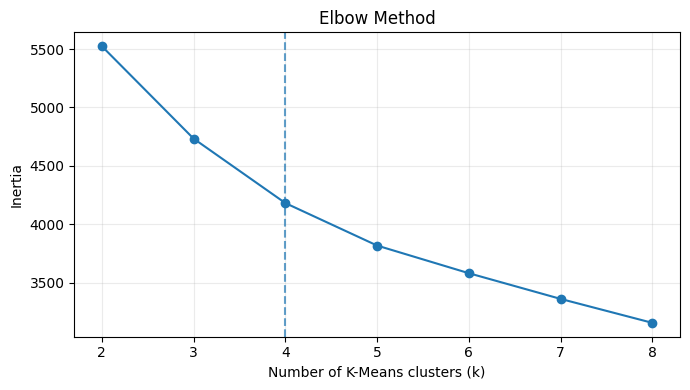

In [ ]:
# Elbow Method
plt.figure(figsize=(7, 4))
plt.plot(
    model_selection["k"],
    model_selection["inertia"],
    marker="o"
)
plt.axvline(4, linestyle="--", alpha=0.7)
plt.xlabel("Number of K-Means clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


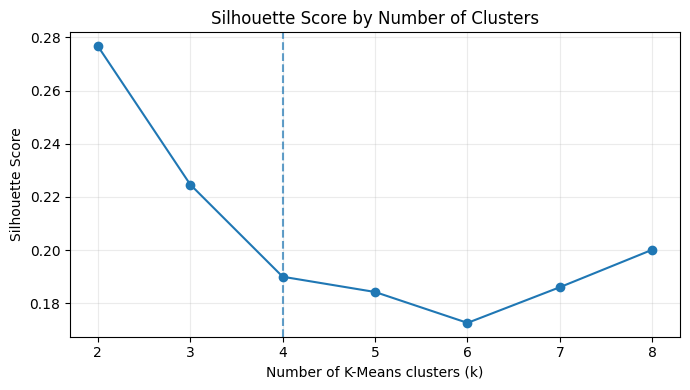

In [ ]:
# Silhouette Score theo k
plt.figure(figsize=(7, 4))
plt.plot(
    model_selection["k"],
    model_selection["silhouette"],
    marker="o"
)
plt.axvline(4, linestyle="--", alpha=0.7)
plt.xlabel("Number of K-Means clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [ ]:
FINAL_K = 4
final_kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=RANDOM_STATE,
    n_init=50
)

full_year_labels = (
    final_kmeans.fit_predict(
        X_full_scaled
    )
)

customer_full_year[
    "kmeans_cluster_id"
] = full_year_labels

customer_full_year[
    "segment_id"
] = full_year_labels

## Segment dành cho customer không đủ năm

91 customer không đủ 12 tháng được gán vào một segment riêng thay vì được dự đoán bằng K-Means.

Segment này phản ánh **insufficient observation history**, không phản ánh một behavioral pattern được phát hiện bởi thuật toán.

Để tránh nhầm lẫn với các behavioral clusters:

- `kmeans_cluster_id = -1` đối với nhóm này;
- `segment_id = K`, tức ID tiếp theo sau các cluster của K-Means;
- `segment_type = "Partial-year / insufficient history"`.

Các customer trong nhóm này vẫn được giữ trong kết quả cuối nhằm bảo đảm 100% population coverage.


In [ ]:
# ============================================================
# TẠO SEGMENT RIÊNG CHO 91 CUSTOMER KHÔNG ĐỦ NĂM
# ============================================================

PARTIAL_SEGMENT_ID = FINAL_K

customer_partial_year[
    "kmeans_cluster_id"
] = -1

customer_partial_year[
    "segment_id"
] = PARTIAL_SEGMENT_ID

customer_partial_year[
    "segment_type"
] = "Partial-year / insufficient history"

customer_full_year[
    "segment_type"
] = "K-Means behavioral cluster"

In [ ]:
segmented_customers = pd.concat(
    [
        customer_full_year,
        customer_partial_year
    ],
    axis=0
).sort_index()

In [ ]:
print(
    "Tổng số customer:",
    len(segmented_customers)
)

print(
    "Số segment cuối cùng:",
    segmented_customers[
        "segment_id"
    ].nunique()
)

print(
    "Population coverage:",
    segmented_customers[
        "segment_id"
    ].notna().mean() * 100,
    "%"
)

print(
    "Tổng số NaN:",
    segmented_customers
    .isna()
    .sum()
    .sum()
)

Tổng số customer: 999
Số segment cuối cùng: 5
Population coverage: 100.0 %
Tổng số NaN: 0


## Validation

Các internal clustering metrics chỉ được tính trên **908 customer đủ 12 tháng**, vì đây là tập dữ liệu được sử dụng để xây dựng K-Means.

Segment gồm 91 customer không đủ năm không được đưa vào:

- Silhouette Score;
- Calinski–Harabasz Index;
- Davies–Bouldin Index;
- K-Means stability analysis.

Lý do là segment này được xác định bằng quy tắc về độ đầy đủ dữ liệu, không được hình thành từ khoảng cách đến centroid.

Do đó cần phân biệt:

- **Model validation:** áp dụng cho 908 customer và K behavioral clusters.
- **Population coverage:** đánh giá trên toàn bộ 999 customer và K+1 final segments.


In [ ]:
final_silhouette = silhouette_score(
    X_full_scaled,
    full_year_labels
)

final_ch = calinski_harabasz_score(
    X_full_scaled,
    full_year_labels
)

final_db = davies_bouldin_score(
    X_full_scaled,
    full_year_labels
)

print(
    f"Silhouette Score   : {final_silhouette:.4f}"
)

print(
    f"Calinski-Harabasz  : {final_ch:.2f}"
)

print(
    f"Davies-Bouldin     : {final_db:.4f}"
)

Silhouette Score   : 0.1900
Calinski-Harabasz  : 222.23
Davies-Bouldin     : 1.5239


In [ ]:

kmeans_cluster_size = (
    customer_full_year[
        "segment_id"
    ]
    .value_counts()
    .sort_values(ascending=False)
    .rename("n_customers")
    .to_frame()
)

kmeans_cluster_size[
    "percentage_full_year"
] = (
    kmeans_cluster_size[
        "n_customers"
    ]
    / len(customer_full_year)
    * 100
)

display(
    kmeans_cluster_size.round(2)
)


,n_customers,percentage_full_year
segment_id,,
0,326,35.90
1,208,22.91
3,198,21.81
2,176,19.38


In [ ]:

population_segment_size = (
    segmented_customers[
        "segment_id"
    ]
    .value_counts()
    .sort_values(ascending=False)
    .rename("n_customers")
    .to_frame()
)

population_segment_size[
    "percentage_population"
] = (
    population_segment_size[
        "n_customers"
    ]
    / len(segmented_customers)
    * 100
)

display(
    population_segment_size.round(2)
)


,n_customers,percentage_population
segment_id,,
0,326,32.63
1,208,20.82
3,198,19.82
2,176,17.62
4,91,9.11


## Đặt tên business cho các segment

Tên segment được đặt dựa trên các đặc trưng nổi bật của centroid và các score dùng để profiling. Các tên trong đề bài là **gợi ý, không bắt buộc**, vì vậy tên được điều chỉnh nhẹ để không mâu thuẫn với ngưỡng score thực tế.

- **Segment 0 — Financially Stable & Highly Engaged:** có `spend_to_income_ratio` và `credit_utilization` thấp nhất, trong khi engagement vẫn cao.
- **Segment 1 — Financially Stretched but Highly Engaged:** có áp lực chi tiêu và sử dụng tín dụng cao nhất nhưng vẫn duy trì mức tương tác cao.
- **Segment 2 — Emerging Digital Customers:** có `online_spend_ratio`, transaction count, category diversity và engagement cao nhất; đồng thời có độ tuổi trung bình trẻ nhất.
- **Segment 3 — Lower Engagement & Financially Pressured:** có transaction count thấp nhất, recency cao nhất và category diversity thấp nhất; áp lực tài chính cũng cao hơn nhóm ổn định.
- **Segment 4 — Limited-History Customers:** 91 customer chỉ có 1–2 tháng dữ liệu; đây là segment dựa trên độ phủ dữ liệu, không phải K-Means cluster.

Cụm 0 không gọi là “Financially Healthy” theo nghĩa ngưỡng `financial_health_score >= 80`, vì điểm trung bình của nhóm vẫn thuộc mức **Ổn định**. Tương tự, “Lower Engagement” ở cụm 3 mang ý nghĩa **thấp hơn tương đối so với các behavioral clusters khác**, không đồng nghĩa với `engagement_score < 40`.


In [ ]:
segment_label_map = {
    0: "Financially Stable & Highly Engaged",
    1: "Financially Stretched but Highly Engaged",
    2: "Emerging Digital Customers",
    3: "Lower Engagement & Financially Pressured",
    4: "Limited-History Customers",
}

segment_short_map = {
    0: "Stable & Engaged",
    1: "Stretched & Engaged",
    2: "Emerging Digital",
    3: "Lower Engagement",
    4: "Limited History",
}

segmented_customers["segment_name"] = (
    segmented_customers["segment_id"].map(segment_label_map)
)

customer_full_year["segment_name"] = (
    customer_full_year["segment_id"].map(segment_label_map)
)

customer_partial_year["segment_name"] = (
    customer_partial_year["segment_id"].map(segment_label_map)
)

assert segmented_customers["segment_name"].isna().sum() == 0

display(
    segmented_customers[
        ["segment_id", "segment_name", "segment_type"]
    ]
    .drop_duplicates()
    .sort_values("segment_id")
)


,segment_id,segment_name,segment_type
consumer_id,,,
KH00100045,0,Financially Stable & Highly Engaged,K-Means behavioral cluster
KH00100050,1,Financially Stretched but Highly Engaged,K-Means behavioral cluster
KH00100010,2,Emerging Digital Customers,K-Means behavioral cluster
KH00100170,3,Lower Engagement & Financially Pressured,K-Means behavioral cluster
KH00100090,4,Limited-History Customers,Partial-year / insufficient history


In [ ]:

# ============================================================
# MÀU SẮC NHẤT QUÁN CHO 5 FINAL SEGMENTS
# ============================================================

segment_colors = {
    0: "#1557B0",   # Financially Stable & Highly Engaged
    1: "#159A9C",   # Financially Stretched but Highly Engaged
    2: "#8E44C7",   # Emerging Digital Customers
    3: "#F5822A",   # Lower Engagement & Financially Pressured
    4: "#8A96A3",   # Limited-History Customers
}

# ============================================================
# THỨ TỰ HIỂN THỊ: GIẢM DẦN THEO SỐ LƯỢNG CUSTOMER
# ============================================================

segment_counts = (
    segmented_customers["segment_id"]
    .value_counts()
    .sort_values(ascending=False)
)

segment_order = segment_counts.index.tolist()

# Riêng các bảng/biểu đồ chỉ có 4 K-Means clusters
kmeans_segment_order = [
    segment_id
    for segment_id in segment_order
    if segment_id != PARTIAL_SEGMENT_ID
]

print("Segment order by customer count:", segment_order)
display(
    segment_counts
    .rename("n_customers")
    .to_frame()
)


Segment order by customer count: [0, 1, 3, 2, 4]


,n_customers
segment_id,
0,326
1,208
3,198
2,176
4,91


In [ ]:

centroid_profile = pd.DataFrame(
    final_kmeans.cluster_centers_,
    columns=selected_features
)

centroid_profile.index.name = (
    "segment_id"
)

centroid_profile = centroid_profile.reindex(
    kmeans_segment_order
)

display(
    centroid_profile.round(2)
)


,spend_to_income_ratio_mean,credit_utilization_ratio_mean,spending_volatility_mean,essential_spend_ratio_mean,transaction_count_mean,transaction_recency_days_mean,online_spend_ratio_mean,category_diversity_mean
segment_id,,,,,,,,
0,-0.66,-0.65,0.53,0.39,0.35,-0.41,-0.30,0.45
1,0.92,0.92,0.48,0.35,0.16,-0.35,-0.07,0.35
3,0.28,0.26,-0.52,0.17,-1.19,1.38,-0.11,-1.64
2,-0.18,-0.17,-0.96,-1.31,0.48,-0.37,0.77,0.59


In [ ]:

profile_features = [
    "financial_health_score_mean",
    "engagement_score_mean",

    "spend_to_income_ratio_mean",
    "credit_utilization_ratio_mean",
    "spending_volatility_mean",

    "essential_spend_ratio_mean",
    "discretionary_spend_ratio_mean",
    "online_spend_ratio_mean",

    "transaction_count_mean",
    "active_transaction_days_mean",
    "transaction_recency_days_mean",
    "category_diversity_mean",
]

profile_features = [
    col
    for col in profile_features
    if col in customer_full_year.columns
]

behavioral_profile = (
    customer_full_year
    .groupby("segment_id")[
        profile_features
    ]
    .mean()
    .reindex(kmeans_segment_order)
)

display(
    behavioral_profile.round(3)
)


,financial_health_score_mean,engagement_score_mean,spend_to_income_ratio_mean,credit_utilization_ratio_mean,spending_volatility_mean,essential_spend_ratio_mean,discretionary_spend_ratio_mean,online_spend_ratio_mean,transaction_count_mean,active_transaction_days_mean,transaction_recency_days_mean,category_diversity_mean
segment_id,,,,,,,,,,,,
0,68.776,78.800,0.602,0.155,1.789,0.508,0.492,0.196,201.422,29.904,0.012,13.892
1,61.844,78.856,0.837,0.244,1.771,0.505,0.495,0.204,184.595,29.702,0.017,13.859
3,66.220,73.865,0.742,0.207,1.357,0.494,0.506,0.203,64.229,25.516,0.182,13.185
2,67.448,80.566,0.673,0.182,1.170,0.402,0.598,0.232,213.149,29.731,0.016,13.938


### Profile của Partial-Year Segment

Nhóm customer không đủ năm được mô tả riêng.

Các metric của nhóm này cần được diễn giải thận trọng vì chúng được tính từ chỉ 1–2 tháng quan sát, trong khi behavioral clusters được xây dựng từ customer có đủ 12 tháng.

Vì vậy, profile của nhóm này chủ yếu dùng để mô tả:

- số tháng quan sát;
- demographic composition;
- financial-health / engagement status trong khoảng thời gian có dữ liệu;
- phạm vi các feature được quan sát.

Không nên trực tiếp kết luận rằng sự khác biệt giữa nhóm này và các full-year clusters phản ánh hành vi dài hạn.


In [ ]:
partial_profile = (
    customer_partial_year[
        [
            "n_months_observed",
            "financial_health_score_mean",
            "engagement_score_mean",
            "spend_to_income_ratio_mean",
            "credit_utilization_ratio_mean",
            "spending_volatility_mean",
            "essential_spend_ratio_mean",
            "online_spend_ratio_mean",
            "transaction_count_mean",
            "transaction_recency_days_mean",
            "category_diversity_mean",
        ]
    ]
    .describe()
    .T
)

display(
    partial_profile.round(3)
)

,count,mean,std,min,25%,50%,75%,max
n_months_observed,91.0,1.055,0.229,1.000,1.000,1.000,1.000,2.000
financial_health_score_mean,91.0,65.599,6.710,48.200,60.500,65.100,70.700,77.300
engagement_score_mean,91.0,48.685,8.527,12.800,46.550,49.600,54.250,61.600
spend_to_income_ratio_mean,91.0,0.619,0.130,0.361,0.524,0.619,0.706,0.939
credit_utilization_ratio_mean,91.0,0.176,0.058,0.085,0.129,0.182,0.214,0.378
spending_volatility_mean,91.0,0.685,0.228,0.238,0.511,0.672,0.812,1.321
essential_spend_ratio_mean,91.0,0.154,0.151,0.000,0.070,0.111,0.197,1.000
online_spend_ratio_mean,91.0,0.654,0.201,0.000,0.591,0.693,0.785,0.951
transaction_count_mean,91.0,9.676,2.457,3.500,8.000,10.000,11.000,19.000
transaction_recency_days_mean,91.0,13.176,8.697,0.000,6.000,15.000,20.000,28.000


In [ ]:
def mode_value_profile(x):
    mode = x.mode()

    if len(mode) == 0:
        return "Unknown"

    return mode.iloc[0]


demographic_profile = (
    segmented_customers
    .groupby("segment_id")
    .agg(
        n_customers=(
            "consumer_id",
            "size"
        )
        if "consumer_id"
        in segmented_customers.columns
        else (
            "age",
            "size"
        ),

        age_mean=(
            "age",
            "mean"
        ),

        dominant_age_group=(
            "age_group",
            mode_value_profile
        ),

        dominant_gender=(
            "gender",
            mode_value_profile
        ),

        dominant_occupation_group=(
            "occupation_group",
            mode_value_profile
        ),

        dominant_province=(
            "province_city",
            mode_value_profile
        ),
    )
)

display(
    demographic_profile
)

,n_customers,age_mean,dominant_age_group,dominant_gender,dominant_occupation_group,dominant_province
segment_id,,,,,,
0,326,52.444785,65+,Nữ,Kỹ thuật và xây dựng,Thành phố Hồ Chí Minh
1,208,50.778846,45–54,Nam,"Truyền thông, nghệ thuật và thiết kế",Thành phố Hồ Chí Minh
2,176,35.880682,35–44,Nữ,Y tế và chăm sóc sức khỏe,Thành phố Hồ Chí Minh
3,198,54.156566,65+,Nam,Kỹ thuật và xây dựng,Thành phố Hồ Chí Minh
4,91,58.384615,65+,Nam,"Truyền thông, nghệ thuật và thiết kế",Thành phố Hồ Chí Minh


In [ ]:
demographic_profile = (
    segmented_customers
    .groupby("segment_id")
    .agg(
        n_customers=(
            "age",
            "size"
        ),

        age_mean=(
            "age",
            "mean"
        ),

        dominant_age_group=(
            "age_group",
            mode_value_profile
        ),

        dominant_gender=(
            "gender",
            mode_value_profile
        ),

        dominant_occupation_group=(
            "occupation_group",
            mode_value_profile
        ),

        dominant_province=(
            "province_city",
            mode_value_profile
        ),
    )
)

## Post-Segmentation Analysis

Phần này so sánh **toàn bộ 5 final segments** theo các góc nhìn: quy mô, behavioral drivers, financial health, engagement, digital behavior và demographics.

Trong đó:

- **4 segment đầu** là behavioral clusters được K-Means học từ 908 customer có đủ 12 tháng.
- **Limited-History Customers (91 customer)** là segment được tách bằng rule về độ phủ dữ liệu, không phải kết quả K-Means.

Để các biểu đồ nhất quán, mỗi segment được gán **một màu cố định xuyên suốt toàn bộ phần phân tích**. Limited-History Customers luôn được biểu diễn bằng **màu xám** và, khi phù hợp, bằng marker rỗng hoặc hatch để nhấn mạnh rằng đây là một segment rule-based.

Nhóm 91 customer vẫn được đưa vào các bảng và biểu đồ so sánh nhằm bảo đảm góc nhìn toàn population. Tuy nhiên, các giá trị hành vi của nhóm này chỉ phản ánh **1–2 tháng quan sát**, nên được xem là descriptive profile và không nên diễn giải như hành vi dài hạn tương đương với 4 behavioral clusters.

**Quy ước thứ tự hiển thị:** ở tất cả bảng và biểu đồ có các segment theo danh mục hoặc legend, các segment được sắp xếp **giảm dần theo số lượng customer**. Với dữ liệu hiện tại, thứ tự là: **Stable & Engaged → Stretched & Engaged → Lower Engagement → Emerging Digital → Limited History**.


### Quy ước màu sắc

Để tránh thay đổi cách hiểu giữa các biểu đồ, màu của 5 segment được giữ cố định:

- **Xanh dương:** Financially Stable & Highly Engaged
- **Teal:** Financially Stretched but Highly Engaged
- **Tím:** Emerging Digital Customers
- **Cam:** Lower Engagement & Financially Pressured
- **Xám:** Limited-History Customers

Trong các biểu đồ mà màu sắc biểu diễn **một biến khác** (ví dụ age group), một palette riêng sẽ được sử dụng và được giải thích rõ trong legend.


### 6.1. Quy mô và tỷ trọng từng segment

Biểu đồ thể hiện quy mô của **cả 5 final segments** trên tổng population 999 customer.  
`Limited-History Customers` được giữ như một segment riêng và chiếm khoảng 9.1% population.


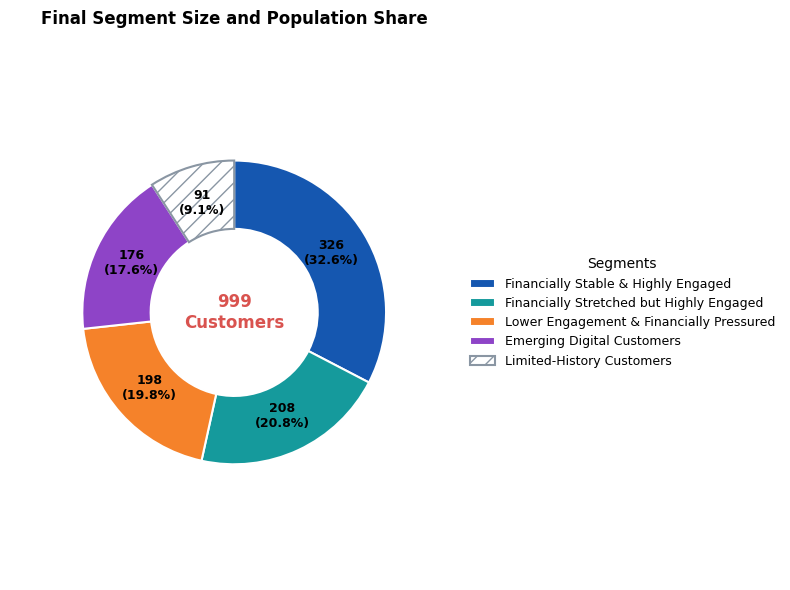

In [ ]:
segment_size_plot = (
    segmented_customers
    .groupby(["segment_id", "segment_name"])
    .size()
    .rename("n_customers")
    .reset_index()
)

# Sắp xếp giảm dần theo số lượng customer
segment_size_plot = (
    segment_size_plot
    .set_index("segment_id")
    .reindex(segment_order)
    .reset_index()
)

segment_size_plot["population_pct"] = (
    segment_size_plot["n_customers"]
    / len(segmented_customers)
    * 100
)

# Màu theo segment
pie_colors = [
    segment_colors[i]
    for i in segment_size_plot["segment_id"]
]

fig, ax = plt.subplots(figsize=(8, 6))

# Hiển thị cả số lượng và tỷ lệ %
def autopct_format(pct):
    total = segment_size_plot["n_customers"].sum()
    n = int(round(pct * total / 100))
    return f"{n}\n({pct:.1f}%)"


wedges, texts, autotexts = ax.pie(
    segment_size_plot["n_customers"],
    colors=pie_colors,
    startangle=90,
    counterclock=False,
    autopct=autopct_format,
    pctdistance=0.75,
    wedgeprops={
        "width": 0.45,
        "edgecolor": "white",
        "linewidth": 1.5
    }
)

# Limited-History: hatch để phân biệt segment rule-based
for wedge, segment_id in zip(
    wedges,
    segment_size_plot["segment_id"]
):
    if segment_id == PARTIAL_SEGMENT_ID:
        wedge.set_facecolor("white")
        wedge.set_edgecolor(segment_colors[segment_id])
        wedge.set_linewidth(1.5)
        wedge.set_hatch("//")


# Format label trong pie
for text in autotexts:
    text.set_fontsize(9)
    text.set_fontweight("bold")


# ==========================================
# THÊM TỔNG SỐ CUSTOMERS VÀO GIỮA - MÀU ĐỎ
# ==========================================
total_customers = segment_size_plot["n_customers"].sum()
ax.text(
    0, 0,
    f"{total_customers:,}\nCustomers",
    ha='center',
    va='center',
    fontsize=12,           # Tăng nhẹ size để nổi bật hơn
    fontweight='bold',
    color='#d9534f'        # Đổi màu chữ thành đỏ (hoặc dùng 'red', '#e74c3c')
)


# Legend
ax.legend(
    wedges,
    segment_size_plot["segment_name"],
    title="Segments",
    loc="center left",
    bbox_to_anchor=(1.00, 0.5),
    frameon=False,
    fontsize=9,
    title_fontsize=10
)

ax.set_title(
    "Final Segment Size and Population Share",
    fontweight="bold",
    pad=15
)

ax.axis("equal")

plt.tight_layout()
plt.show()

### 6.2. So sánh các behavioral drivers của cả 5 segment

Để có thể đặt `Limited-History Customers` cạnh 4 K-Means clusters trên cùng thang đo:

1. Sử dụng **StandardScaler đã fit trên 908 customer đủ năm**.
2. Transform các feature của toàn bộ 999 customer bằng chính scaler đó.
3. Tính **mean z-score theo `segment_id`**.

Với 4 K-Means clusters, các giá trị trung bình chuẩn hóa này tương ứng với profile quanh centroid.  
Với `Limited-History Customers`, đây chỉ là **profile mô tả tương đối so với chuẩn của nhóm full-year**, không phải centroid và không được dùng để fit K-Means.


,Spend / Income,Credit Utilization,Spending Volatility,Essential Spend,Transaction Count,Recency Days,Online Spend,Category Diversity
Stable & Engaged,-0.66,-0.65,0.53,0.39,0.35,-0.41,-0.30,0.45
Stretched & Engaged,0.92,0.92,0.48,0.35,0.16,-0.35,-0.07,0.35
Lower Engagement,0.28,0.26,-0.52,0.17,-1.19,1.38,-0.11,-1.64
Emerging Digital,-0.18,-0.17,-0.96,-1.31,0.48,-0.37,0.77,0.59
Limited History,-0.55,-0.29,-2.13,-5.26,-1.80,138.16,13.23,-26.00


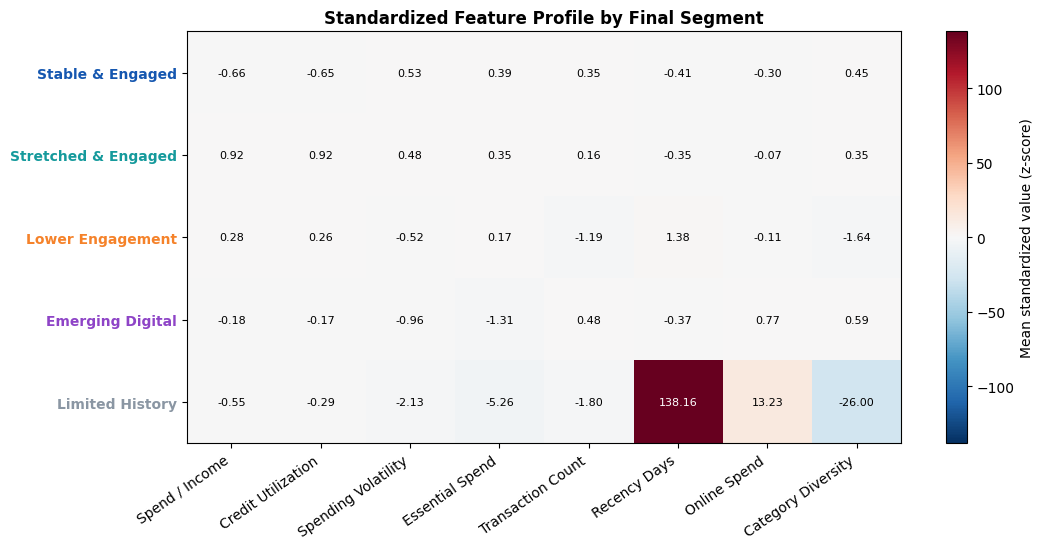

In [ ]:
# ============================================================
# STANDARDIZED FEATURE PROFILE CHO CẢ 5 FINAL SEGMENTS
# ============================================================

X_all = (
    segmented_customers[selected_features]
    .astype(float)
    .copy()
)

# QUAN TRỌNG: dùng scaler đã fit trên 908 full-year customers
X_all_scaled = pd.DataFrame(
    scaler.transform(X_all),
    index=segmented_customers.index,
    columns=selected_features
)

X_all_scaled["segment_id"] = (
    segmented_customers["segment_id"].values
)

segment_feature_profile_z = (
    X_all_scaled
    .groupby("segment_id")[selected_features]
    .mean()
    .reindex(segment_order)
)

segment_feature_profile_z.index = [
    segment_short_map[i]
    for i in segment_feature_profile_z.index
]

feature_display_names = {
    "spend_to_income_ratio_mean": "Spend / Income",
    "credit_utilization_ratio_mean": "Credit Utilization",
    "spending_volatility_mean": "Spending Volatility",
    "essential_spend_ratio_mean": "Essential Spend",
    "transaction_count_mean": "Transaction Count",
    "transaction_recency_days_mean": "Recency Days",
    "online_spend_ratio_mean": "Online Spend",
    "category_diversity_mean": "Category Diversity",
}

segment_feature_profile_z = (
    segment_feature_profile_z
    .rename(columns=feature_display_names)
)

display(segment_feature_profile_z.round(2))

fig, ax = plt.subplots(figsize=(11, 5.6))

max_abs = np.abs(
    segment_feature_profile_z.values
).max()

im = ax.imshow(
    segment_feature_profile_z.values,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-max_abs,
    vmax=max_abs
)

ax.set_xticks(
    np.arange(len(segment_feature_profile_z.columns))
)
ax.set_xticklabels(
    segment_feature_profile_z.columns,
    rotation=35,
    ha="right"
)

ax.set_yticks(
    np.arange(len(segment_feature_profile_z.index))
)
ax.set_yticklabels(
    segment_feature_profile_z.index
)

# Giữ màu segment nhất quán ở nhãn hàng
for tick_label, segment_id in zip(
    ax.get_yticklabels(),
    segment_order
):
    tick_label.set_color(segment_colors[segment_id])
    tick_label.set_fontweight("bold")

for i in range(segment_feature_profile_z.shape[0]):
    for j in range(segment_feature_profile_z.shape[1]):
        value = segment_feature_profile_z.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color=("white" if abs(value) > max_abs * 0.55 else "black")
        )

fig.colorbar(
    im,
    ax=ax,
    label="Mean standardized value (z-score)"
)

ax.set_title(
    "Standardized Feature Profile by Final Segment",
    fontweight="bold"
)

plt.tight_layout()
plt.show()


### 6.3. Financial health và engagement của cả 5 segment

`financial_health_score_mean` và `engagement_score_mean` **không được dùng để tạo K-Means clusters**, nên phù hợp để profiling sau phân khúc.

Scatter plot dưới đây hiển thị từng customer để cho thấy mức độ phân tán và overlap giữa các segment trên hai score tổng hợp:

- X: `financial_health_score_mean`
- Y: `engagement_score_mean`

Các đường nét đứt là trung bình của **908 full-year customers** — chính là population được dùng để fit K-Means. Limited-History Customers được biểu diễn bằng marker rỗng màu xám để phân biệt với 4 behavioral clusters.

Biểu đồ này chỉ phục vụ **profiling**: việc các segment overlap trên hai score không đồng nghĩa K-Means phân cụm kém, vì mô hình được xây dựng trên 8 behavioral features chứ không phải trực tiếp trên hai score này.


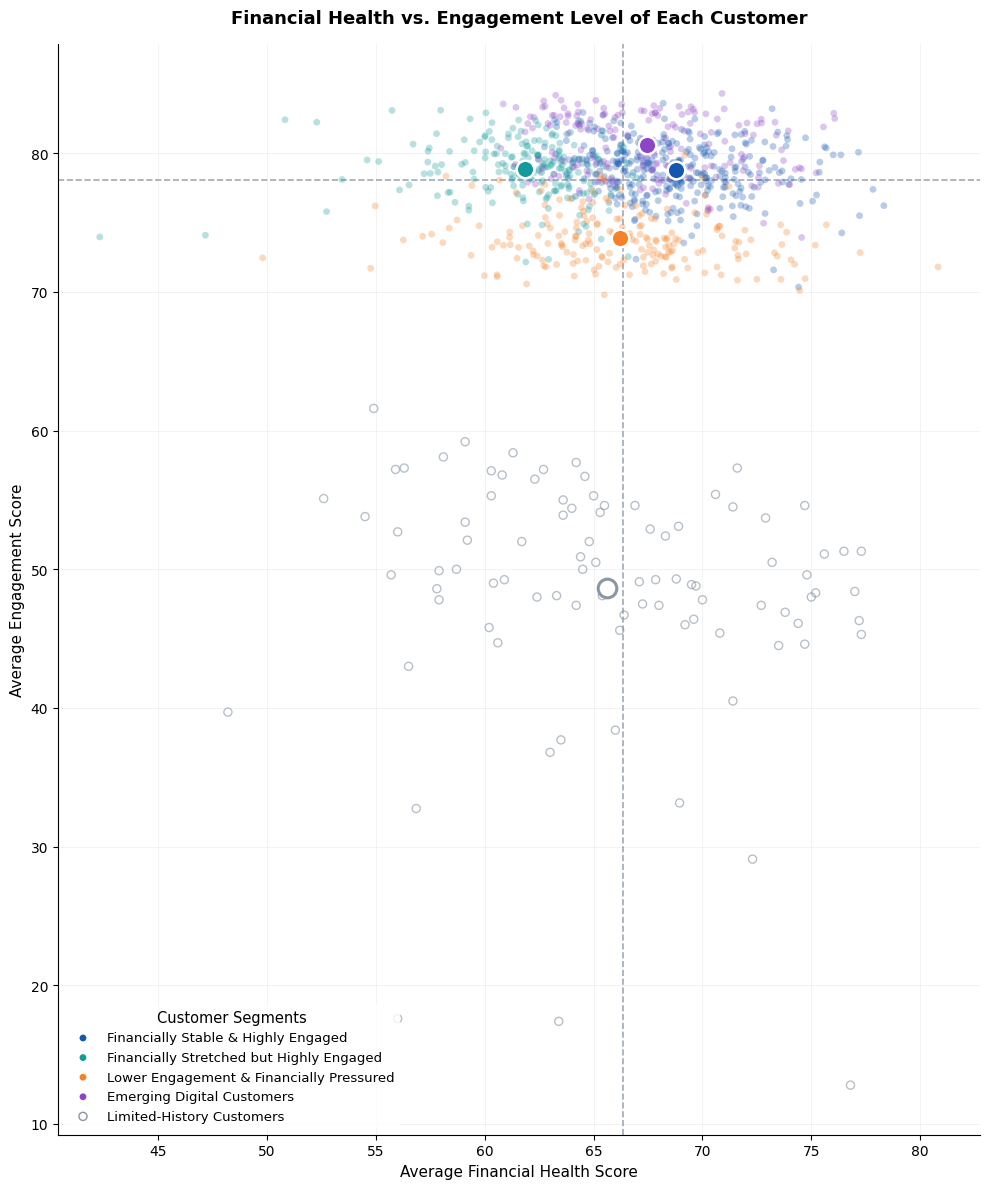

In [ ]:
# ============================================================
# 2. CALCULATE SEGMENT CENTROIDS
# ============================================================

segment_centers = (
    segmented_customers
    .groupby("segment_id")
    .agg(
        financial_health_score=(
            "financial_health_score_mean",
            "mean"
        ),
        engagement_score=(
            "engagement_score_mean",
            "mean"
        ),
        n_customers=(
            "segment_id",
            "size"
        )
    )
    .reindex(segment_order)
)

# ============================================================
# 3. CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(10, 12))

unique_segments = segment_order

# ============================================================
# 4. PLOT CUSTOMERS WITH CORRECT LEGEND LABELS
# ============================================================

for segment_id in unique_segments:
    segment_df = segmented_customers[
        segmented_customers["segment_id"] == segment_id
    ]
    color = segment_colors[segment_id]
    label_name = segment_label_map[segment_id]

    # Limited-History Customers
    if segment_id == PARTIAL_SEGMENT_ID:
        ax.scatter(
            segment_df["financial_health_score_mean"],
            segment_df["engagement_score_mean"],
            s=34,
            facecolors="none",
            edgecolors=color,
            linewidths=1.0,
            alpha=0.60,
            zorder=3,
            label=label_name
        )
    # 4 K-means clusters
    else:
        ax.scatter(
            segment_df["financial_health_score_mean"],
            segment_df["engagement_score_mean"],
            s=24,
            color=color,
            alpha=0.30,
            edgecolors="none",
            zorder=2,
            label=label_name
        )

# ============================================================
# 5. PLOT CENTROIDS
# ============================================================

for segment_id, row in segment_centers.iterrows():
    color = segment_colors[segment_id]

    # Limited-History segment
    if segment_id == PARTIAL_SEGMENT_ID:
        ax.scatter(
            row["financial_health_score"],
            row["engagement_score"],
            s=180,
            facecolors="white",
            edgecolors=color,
            linewidths=2.2,
            zorder=6
        )
    # K-means clusters
    else:
        ax.scatter(
            row["financial_health_score"],
            row["engagement_score"],
            s=160,
            color=color,
            edgecolors="white",
            linewidths=1.8,
            zorder=6
        )

# ============================================================
# 6. REFERENCE LINES (Calculated on 908 full-year customers)
# ============================================================

financial_mean = (
    customer_full_year[
        "financial_health_score_mean"
    ].mean()
)

engagement_mean = (
    customer_full_year[
        "engagement_score_mean"
    ].mean()
)

ax.axvline(
    financial_mean,
    color="#7A8594",
    linestyle="--",
    linewidth=1.2,
    alpha=0.70,
    zorder=1
)

ax.axhline(
    engagement_mean,
    color="#7A8594",
    linestyle="--",
    linewidth=1.2,
    alpha=0.70,
    zorder=1
)

# ============================================================
# 7. AXES LABELS & TITLE (TRANSLATED TO ENGLISH)
# ============================================================

ax.set_xlabel(
    "Average Financial Health Score",
    fontsize=11
)

ax.set_ylabel(
    "Average Engagement Score",
    fontsize=11
)

ax.set_title(
    "Financial Health vs. Engagement Level of Each Customer",
    fontsize=13,
    fontweight="bold",
    pad=15
)

# ============================================================
# 8. STYLE & LEGEND
# ============================================================

ax.grid(
    alpha=0.15,
    linewidth=0.7
)

ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

leg = ax.legend(
    title="Customer Segments",
    loc="lower left",
    frameon=True,
    facecolor="white",
    edgecolor="none",
    fontsize=9.5,
    title_fontsize=10.5
)

for lh in leg.legend_handles:
    lh.set_alpha(1.0)

# ============================================================
# 9. DISPLAY
# ============================================================

plt.tight_layout()
plt.show()


### 6.4. So sánh các key ratio metrics trên cùng thang đo

Trong 8 modeling features, bốn biến sau đều là **ratio** và có thể chuyển trực tiếp sang phần trăm để so sánh trên **cùng một trục tung 0–100%**:

- `spend_to_income_ratio_mean`: mức chi tiêu so với thu nhập;
- `credit_utilization_ratio_mean`: mức sử dụng hạn mức tín dụng;
- `essential_spend_ratio_mean`: tỷ trọng chi tiêu thiết yếu;
- `online_spend_ratio_mean`: tỷ trọng chi tiêu online.

Grouped bar chart dưới đây giúp quan sát đồng thời **financial pressure, spending composition và digital adoption** của cả 5 final segments mà không cần chuẩn hóa về z-score.

`Limited-History Customers` được thể hiện bằng cột rỗng có hatch vì profile của nhóm chỉ dựa trên 1–2 tháng quan sát.


,Spend-to-Income Ratio,Credit Utilization Ratio,Essential Spend Ratio,Online Spend Ratio
segment_id,,,,
0,60.2,15.5,50.8,19.6
1,83.7,24.4,50.5,20.4
3,74.2,20.7,49.4,20.3
2,67.3,18.2,40.2,23.2
4,61.9,17.6,15.4,65.4


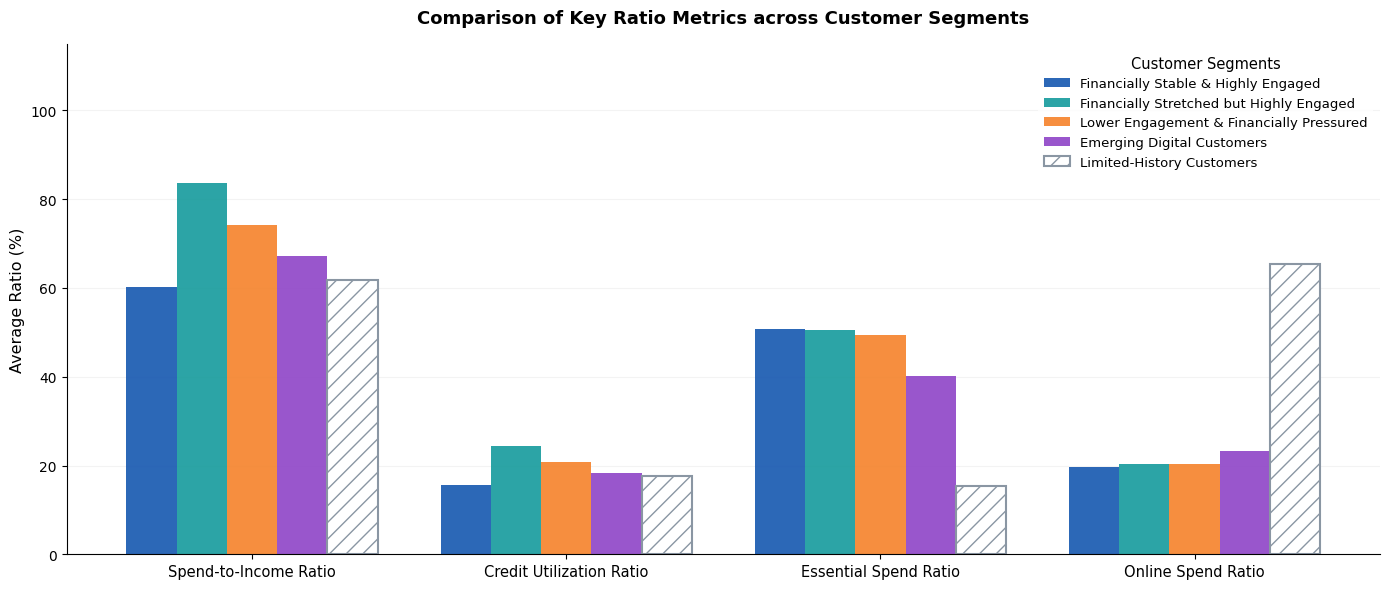

In [ ]:
ratio_features = [
    "spend_to_income_ratio_mean",
    "credit_utilization_ratio_mean",
    "essential_spend_ratio_mean",
    "online_spend_ratio_mean",
]

metric_labels = {
    "spend_to_income_ratio_mean": "Spend-to-Income Ratio",
    "credit_utilization_ratio_mean": "Credit Utilization Ratio",
    "essential_spend_ratio_mean": "Essential Spend Ratio",
    "online_spend_ratio_mean": "Online Spend Ratio",
}

ratio_profile = (
    segmented_customers
    .groupby("segment_id")[ratio_features]
    .mean()
    .reindex(segment_order)
    * 100
)

ratio_profile = ratio_profile.rename(
    columns=metric_labels
)

display(ratio_profile.round(1))

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(ratio_profile.columns))
n_segments = len(ratio_profile.index)
total_width = 0.80
bar_width = total_width / n_segments

for i, segment_id in enumerate(ratio_profile.index):
    offset = (
        i - (n_segments - 1) / 2
    ) * bar_width

    values = ratio_profile.loc[segment_id].values
    color = segment_colors[segment_id]

    if segment_id == PARTIAL_SEGMENT_ID:
        ax.bar(
            x + offset,
            values,
            width=bar_width,
            facecolor="white",
            edgecolor=color,
            linewidth=1.5,
            hatch="//",
            label=segment_label_map[segment_id]
        )
    else:
        ax.bar(
            x + offset,
            values,
            width=bar_width,
            color=color,
            alpha=0.90,
            label=segment_label_map[segment_id]
        )

ax.set_xticks(x)
ax.set_xticklabels(ratio_profile.columns, fontsize=10.5)
ax.set_ylabel("Average Ratio (%)", fontsize=11.5)
ax.set_ylim(0, 115)
ax.set_title(
    "Comparison of Key Ratio Metrics across Customer Segments",
    fontweight="bold",
    fontsize=13,
    pad=15
)
ax.grid(axis="y", alpha=0.15)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Customer Segments",
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="none",
    fontsize=9.5,
    title_fontsize=10.5
)

plt.tight_layout()
plt.show()

### 6.5. Engagement behavior: transaction frequency và recency

Hai biến này phản ánh hai chiều bổ sung của engagement:

- `transaction_count_mean`: mức độ hoạt động giao dịch;
- `transaction_recency_days_mean`: số ngày kể từ giao dịch gần nhất, trong đó giá trị cao hơn hàm ý hoạt động kém gần đây hơn.

Để biểu đồ phù hợp với mục tiêu **so sánh segment trên slide**, thay vì hiển thị gần 1.000 điểm customer-level, mỗi điểm dưới đây đại diện cho **giá trị trung bình của một final segment**. Điều này giúp nhìn rõ hơn vị trí tương đối giữa 5 nhóm.

Limited-History Customers vẫn được hiển thị nhưng bằng marker rỗng màu xám để nhắc rằng đây là segment rule-based.


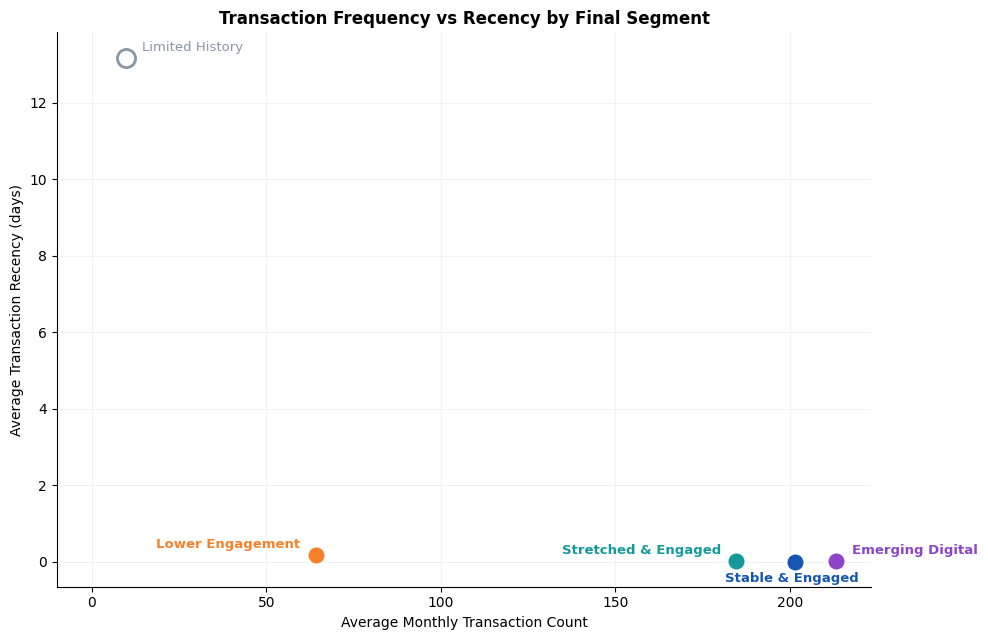

In [ ]:
engagement_profile = (
    segmented_customers
    .groupby("segment_id")
    .agg(
        transaction_count=("transaction_count_mean", "mean"),
        recency_days=("transaction_recency_days_mean", "mean")
    )
    .reindex(segment_order)
)

fig, ax = plt.subplots(figsize=(10, 6.5))

# Fine-tuned annotation offsets to completely avoid overlap
annotation_offsets = {
    0: (-50, -15),   # Stable & Engaged: Moved up and right
    1: (-125, 5),  # Stretched & Engaged: Moved down and right
    2: (12, 5),   # Emerging Digital: Moved slightly down and right
    3: (-115, 5),  # Lower Engagement: Moved to the left of the dot
    4: (12, 5),    # Limited History: Moved right
}

for segment_id, row in engagement_profile.iterrows():
    color = segment_colors[segment_id]

    if segment_id == PARTIAL_SEGMENT_ID:
        ax.scatter(
            row["transaction_count"],
            row["recency_days"],
            s=170,
            facecolors="white",
            edgecolors=color,
            linewidths=2.0,
            zorder=4
        )
    else:
        ax.scatter(
            row["transaction_count"],
            row["recency_days"],
            s=170,
            color=color,
            edgecolors="white",
            linewidths=1.5,
            zorder=4
        )

    ax.annotate(
        segment_short_map[segment_id],
        (row["transaction_count"],
         row["recency_days"]),
        xytext=annotation_offsets[segment_id],
        textcoords="offset points",
        fontsize=9.5,
        color=color,
        fontweight="bold" if segment_id != PARTIAL_SEGMENT_ID else "normal"
    )

ax.set_xlabel("Average Monthly Transaction Count")
ax.set_ylabel("Average Transaction Recency (days)")
ax.set_title(
    "Transaction Frequency vs Recency by Final Segment",
    fontweight="bold"
)
ax.grid(alpha=0.15)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Adjust x limit to ensure left-side annotation is not cut off
ax.set_xlim(left=-10)

plt.tight_layout()
plt.show()

### 6.6. Demographic profile của cả 5 segment

Demographics không tham gia tạo cluster mà chỉ được dùng để mô tả population sau phân khúc.

Biểu đồ 100% stacked bar thể hiện cơ cấu nhóm tuổi của **toàn bộ 5 final segments**, bao gồm `Limited-History Customers`.


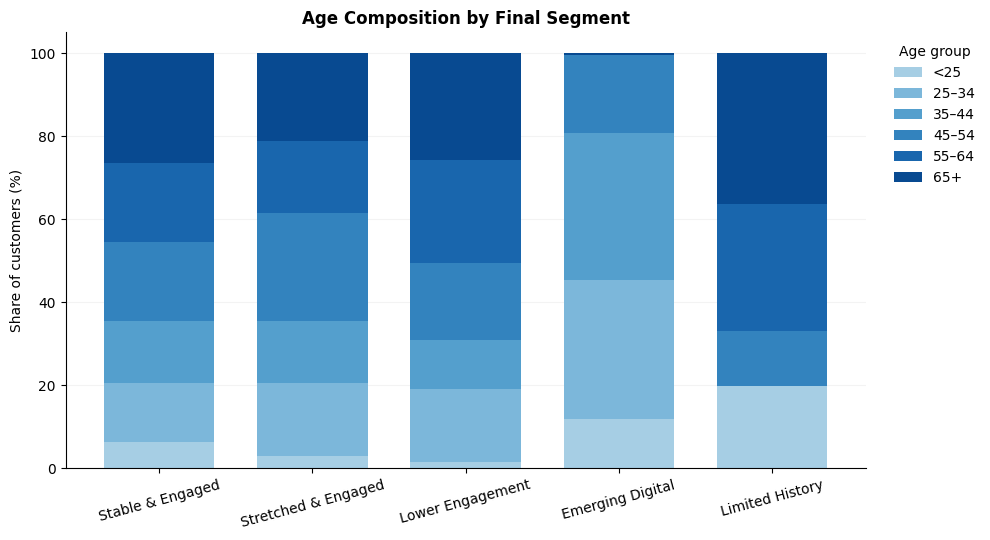

In [ ]:
age_mix = (
    pd.crosstab(
        segmented_customers["segment_id"],
        segmented_customers["age_group"],
        normalize="index"
    )
    .reindex(segment_order)
    * 100
)

age_mix.index = [
    segment_short_map[i]
    for i in age_mix.index
]

# Ở biểu đồ này màu sắc biểu diễn AGE GROUP, không phải segment.
# Vì vậy dùng một palette tuần tự riêng để tránh gây nhầm lẫn.
age_palette = plt.cm.Blues(
    np.linspace(0.35, 0.90, len(age_mix.columns))
)

ax = age_mix.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5.5),
    color=age_palette,
    width=0.72
)

ax.set_xlabel("")
ax.set_ylabel("Share of customers (%)")
ax.set_title("Age Composition by Final Segment", fontweight="bold")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.15)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(
    title="Age group",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()


### 6.7. Độ phủ dữ liệu của Limited-History Customers

Ngoài việc được đưa vào các so sánh ở trên, nhóm 91 customer vẫn cần được kiểm tra riêng về độ phủ dữ liệu.

Biểu đồ dưới đây cho thấy nhóm này chỉ có **1–2 tháng quan sát**, giải thích vì sao họ được tách thành một segment riêng thay vì đưa vào K-Means cùng 908 customer đủ năm.


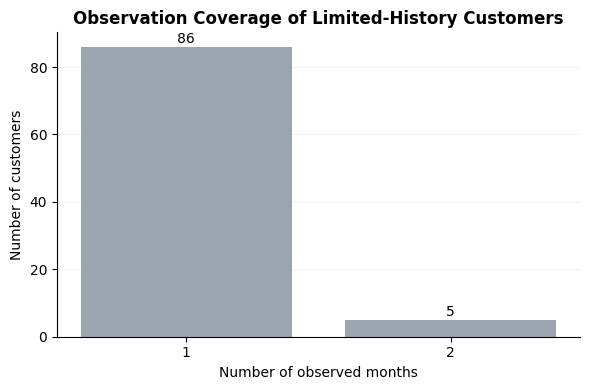

In [ ]:
partial_month_distribution = (
    customer_partial_year["n_months_observed"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    partial_month_distribution.index.astype(str),
    partial_month_distribution.values,
    color=segment_colors[PARTIAL_SEGMENT_ID],
    alpha=0.85
)

for bar, value in zip(
    bars,
    partial_month_distribution.values
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        str(value),
        ha="center"
    )

ax.set_xlabel("Number of observed months")
ax.set_ylabel("Number of customers")
ax.set_title("Observation Coverage of Limited-History Customers", fontweight="bold")
ax.grid(axis="y", alpha=0.15)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


### 6.8. Business-oriented interpretation cho cả 5 segment

Các đề xuất dưới đây áp dụng cho **toàn bộ 5 final segments** và mang tính **non-punitive**, phục vụ engagement và financial wellbeing. `financial_health_score` không được sử dụng để từ chối tín dụng, cắt hạn mức hoặc khóa tài khoản.

- **Financially Stable & Highly Engaged:** duy trì loyalty, cung cấp spending insights và gợi ý sản phẩm phù hợp.
- **Financially Stretched but Highly Engaged:** ưu tiên budgeting tools, spend alerts và financial-planning reminders.
- **Emerging Digital Customers:** tăng digital-channel nudges, trải nghiệm mobile/online và cá nhân hóa nội dung số.
- **Lower Engagement & Financially Pressured:** kết hợp re-engagement nhẹ nhàng với budgeting support; tránh các biện pháp mang tính trừng phạt.
- **Limited-History Customers:** tập trung onboarding, duy trì tương tác cơ bản và thu thập thêm lịch sử trước khi cá nhân hóa sâu.

Với `Limited-History Customers`, recommendation được quyết định chủ yếu bởi **độ thiếu dữ liệu**, không phải bởi một kết luận chắc chắn về behavioral profile dài hạn.


In [ ]:

segment_recommendations = pd.DataFrame({
    "segment_id": [0, 1, 2, 3, 4],
    "segment_name": [
        segment_label_map[i] for i in range(5)
    ],
    "main_profile": [
        "Low financial pressure; high activity and engagement",
        "Highest spend-to-income and credit utilization; engagement remains high",
        "Highest digital usage, transaction frequency and category diversity",
        "Lowest transaction frequency; highest recency; relatively higher financial pressure",
        "Only 1–2 months of observation; insufficient history for annual behavioral inference",
    ],
    "business_direction": [
        "Retention, loyalty, spending insights, relevant product suggestions",
        "Budgeting tools, spend alerts, financial-planning reminders",
        "Digital-channel nudges, mobile/online personalization, digital product discovery",
        "Gentle re-engagement plus budgeting support and reminders",
        "Onboarding and data collection before deeper personalization",
    ],
})

segment_recommendations = (
    segment_recommendations
    .set_index("segment_id")
    .reindex(segment_order)
    .reset_index()
)

display(segment_recommendations)


,segment_id,segment_name,main_profile,business_direction
0,0,Financially Stable & Highly Engaged,Low financial pressure; high activity and enga...,"Retention, loyalty, spending insights, relevan..."
1,1,Financially Stretched but Highly Engaged,Highest spend-to-income and credit utilization...,"Budgeting tools, spend alerts, financial-plann..."
2,3,Lower Engagement & Financially Pressured,Lowest transaction frequency; highest recency;...,Gentle re-engagement plus budgeting support an...
3,2,Emerging Digital Customers,"Highest digital usage, transaction frequency a...","Digital-channel nudges, mobile/online personal..."
4,4,Limited-History Customers,Only 1–2 months of observation; insufficient h...,Onboarding and data collection before deeper p...


## Phần 3: Hạn chế và hướng tiếp theo

### 3.1. Hạn chế của mô hình

1. **Mức độ tách biệt giữa các cluster còn vừa phải.**  
   Với `k = 4`, Silhouette Score khoảng **0.19**, cho thấy các segment có ý nghĩa business nhưng vẫn tồn tại overlap. Vì vậy không nên xem đây là các nhóm khách hàng tách biệt tuyệt đối.

2. **K-Means phụ thuộc vào khoảng cách Euclid và giả định hình dạng cluster tương đối compact.**  
   Nếu cấu trúc customer thực tế phi tuyến, có mật độ khác nhau hoặc cluster không có dạng gần cầu, K-Means có thể chưa mô tả đầy đủ cấu trúc dữ liệu.

3. **Kết quả nhạy với feature selection và weighting.**  
   Mô hình hiện dựa trên 8 behavioral features. Việc thay đổi bộ biến, cách chuẩn hóa hoặc trọng số từng feature có thể làm thay đổi centroid và membership của cluster.

4. **Customer-level aggregation làm giảm thông tin thời gian.**  
   Việc tổng hợp 12 tháng thành các statistic như mean/ratio giúp mô hình gọn và dễ diễn giải, nhưng có thể làm mất seasonality, short-term shocks và behavioral trajectory trong năm.

5. **Limited-History Customers không phải K-Means cluster.**  
   91 customer chỉ có 1–2 tháng dữ liệu được tách riêng theo rule về data coverage. Profile của nhóm này chỉ mang tính mô tả ngắn hạn và không nên so sánh như một behavioral cluster được học từ đủ 12 tháng.

6. **Financial variables trong case study có tính synthetic.**  
   Vì vậy các kết luận nên tập trung vào ratio và behavioral patterns hơn là diễn giải tuyệt đối các mức tiền.

7. **Validation hiện chủ yếu là internal validation.**  
   Silhouette, Calinski–Harabasz, Davies–Bouldin và cluster stability đánh giá cấu trúc phân cụm, nhưng chưa chứng minh rằng segmentation thực sự tạo ra cải thiện về retention, engagement hay financial wellbeing.

### 3.2. Hướng phát triển tiếp theo

1. **Benchmark với các phương pháp clustering khác.**  
   So sánh K-Means với Gaussian Mixture Model, Hierarchical Clustering hoặc K-Medoids để kiểm tra mức độ ổn định và khả năng mô tả cấu trúc phi tuyến.

2. **Bổ sung temporal features và longitudinal segmentation.**  
   Khai thác trend, rolling-window statistics, behavioral trajectories hoặc sequence-based clustering thay vì chỉ dựa trên annual averages.

3. **Theo dõi stability và segment migration theo thời gian.**  
   Re-run segmentation định kỳ để phát hiện drift, kiểm tra khách hàng chuyển segment như thế nào và đánh giá độ bền của các centroid.

4. **Tái phân loại Limited-History Customers khi đủ dữ liệu.**  
   Khi customer tích lũy đủ lịch sử, chuyển họ từ rule-based segment sang behavioral clustering thay vì giữ cố định trong nhóm Limited-History.

5. **Mở rộng feature space.**  
   Có thể bổ sung customer lifecycle, product ownership, channel usage, merchant/category patterns, campaign response và các biến hành vi khác có ý nghĩa business.

6. **Thực hiện external validation bằng business outcomes.**  
   Kiểm tra khả năng phân biệt churn, retention, campaign response, engagement change hoặc future financial-health outcomes giữa các segment.

7. **Đánh giá hiệu quả của segment-specific interventions.**  
   Thiết kế A/B test cho budgeting tools, digital nudges, re-engagement campaign hoặc onboarding strategy để kiểm tra segmentation có thực sự cải thiện outcome hay không.


In [ ]:
future_work_summary = pd.DataFrame({
    "Limitation": [
        "Moderate cluster separation",
        "Sensitivity to K-Means assumptions and feature selection",
        "Loss of temporal detail after annual aggregation",
        "Limited-History segment is rule-based",
        "Validation is mainly internal",
    ],
    "Future Work": [
        "Benchmark alternative clustering methods",
        "Run feature robustness and weighting tests",
        "Add temporal / longitudinal features",
        "Reclassify customers once sufficient history is available",
        "Validate segments with business outcomes and A/B tests",
    ],
})

display(future_work_summary)


,Limitation,Future Work
0,Moderate cluster separation,Benchmark alternative clustering methods
1,Sensitivity to K-Means assumptions and feature...,Run feature robustness and weighting tests
2,Loss of temporal detail after annual aggregation,Add temporal / longitudinal features
3,Limited-History segment is rule-based,Reclassify customers once sufficient history i...
4,Validation is mainly internal,Validate segments with business outcomes and A...
